# Projek Akhir Data Mining (Granularitas Bulanan dengan K-Medoids)
**Perbandingan K-Means, DBSCAN, Hierarchical Clustering, dan K-Medoids untuk Klasterisasi Stabilitas Mata Uang ASEAN terhadap USD di Era Dedolarisasi**

Notebook ini mengimplementasikan pipeline data mulai dari Data Acquisition, Preprocessing (Agregasi Bulanan), Modeling, Evaluation, hingga Visualization.


---
## Fase 1: Business Understanding (CRISP-DM)

**Tujuan:** Mengidentifikasi pola pengelompokkan stabilitas mata uang ASEAN (IDR, MYR, THB, PHP, SGD, VND)
terhadap USD pada era dedolarisasi (2015–2025).

**Stakeholder utama:** Bank sentral negara ASEAN.

**Kebutuhan bisnis:**
- Instrumen monitoring stabilitas mata uang berbasis data
- Evaluasi kebijakan moneter dan intervensi pasar
- Deteksi anomali (krisis) pada bulan-bulan tertentu
- Koordinasi kebijakan regional (LCT – Local Currency Transaction)

**Kriteria sukses:**
- Menghasilkan klaster mata uang yang terinterpretasi secara ekonomi (Stable/Moderate/Vulnerable)
- Algoritma terbaik berdasarkan Silhouette Score, DBI, dan CHI
- Dashboard interaktif untuk visualisasi hasil clustering


## 1. Instalasi dan Import Library
Diperlukan pustaka `yfinance` untuk mengambil data kurs mata uang, `kneed` untuk deteksi elbow otomatis, dan pustaka standar analisis data lainnya.


In [27]:
# Tambahkan di bagian install jika belum tersedia
# %pip install yfinance pandas numpy matplotlib seaborn scikit-learn scipy kneed


In [28]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
import scipy.cluster.hierarchy as sch

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Custom K-Medoids (PAM) Implementation to bypass Windows compilation issues with scikit-learn-extra
class SimpleKMedoids:
    def __init__(self, n_clusters=3, max_iter=300, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.medoids_ = None
        self.labels_ = None
        
    def fit(self, X):
        np.random.seed(self.random_state)
        n_samples = X.shape[0]
        medoid_indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.medoids_ = X[medoid_indices]
        
        def get_distances(X, medoids):
            dists = np.zeros((X.shape[0], medoids.shape[0]))
            for i, m in enumerate(medoids):
                dists[:, i] = np.sqrt(np.sum((X - m) ** 2, axis=1))
            return dists

        for _ in range(self.max_iter):
            dists = get_distances(X, self.medoids_)
            labels = np.argmin(dists, axis=1)
            
            new_medoid_indices = np.zeros(self.n_clusters, dtype=int)
            for k in range(self.n_clusters):
                cluster_points_idx = np.where(labels == k)[0]
                if len(cluster_points_idx) == 0:
                    new_medoid_indices[k] = medoid_indices[k]
                    continue
                cluster_points = X[cluster_points_idx]
                intra_dists = np.zeros(len(cluster_points))
                for idx, p in enumerate(cluster_points):
                    intra_dists[idx] = np.sum(np.sqrt(np.sum((cluster_points - p) ** 2, axis=1)))
                best_point_idx = cluster_points_idx[np.argmin(intra_dists)]
                new_medoid_indices[k] = best_point_idx
                
            if not np.array_equal(medoid_indices, new_medoid_indices):
                medoid_indices = new_medoid_indices
                self.medoids_ = X[medoid_indices]
            else:
                break
                
        self.labels_ = labels
        return self
        
    def fit_predict(self, X):
        self.fit(X)
        return self.labels_


---
## Fase 2: Data Understanding (CRISP-DM)

**Sumber data:**
1. **Yahoo Finance** (via `yfinance`) — Data kurs harian 6 mata uang ASEAN terhadap USD
2. **World Bank Open Data** — Tingkat Inflasi Tahunan (CPI)

**Periode:** Januari 2015 – Desember 2025

**Eksplorasi awal:** Distribusi data, missing values, korelasi antar variabel, visualisasi time series.


## 2. Data Acquisition
Mendapatkan data harian nilai tukar untuk mata uang ASEAN (IDR, MYR, THB, PHP, SGD, VND) terhadap USD menggunakan `yfinance`.
Rentang waktu: **Januari 2015 s.d. Akhir Tahun 2025** (Atau tanggal terakhir yang tersedia)

Selain itu, mengintegrasikan data **Tingkat Inflasi Tahunan (%)** dari Bank Dunia (file eksternal).


In [29]:
# Definisi parameter
tickers = {
    'IDR': 'IDR=X',
    'MYR': 'MYR=X',
    'THB': 'THB=X',
    'PHP': 'PHP=X',
    'SGD': 'SGD=X',
    'VND': 'VND=X'
}
start_date = '2015-01-01'
end_date = '2026-01-01' # Sampai akhir 2025

# 1. Mengunduh data yfinance
print("Mengunduh data nilai tukar dari Yahoo Finance...")
df_kurs = yf.download(list(tickers.values()), start=start_date, end=end_date)['Close']
# Ubah nama kolom agar menggunakan kode mata uang (bukan ticker yahoo)
reverse_tickers = {v: k for k, v in tickers.items()}
df_kurs.rename(columns=reverse_tickers, inplace=True)

# 2. Membaca data Inflasi dari CSV World Bank
print("\nMembaca data inflasi dari file CSV...")
# Coba path relatif dulu, fallback ke absolut
import os
notebook_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
csv_rel_path = os.path.join(notebook_dir, 'Inflation, consumer prices (annual %)',
                            'API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_250039.csv')
csv_abs_path = r"D:\Tugas Kuliah\Semester 4\Data Mining\Final Project\Inflation, consumer prices (annual %)\API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_250039.csv"

if os.path.exists(csv_rel_path):
    csv_path = csv_rel_path
    print(f"Menggunakan path relatif: {csv_rel_path}")
else:
    csv_path = csv_abs_path
    print(f"Path relatif tidak ditemukan, fallback ke: {csv_abs_path}")

# Skip 4 baris pertama karena format dari World Bank metadata
df_inflation_raw = pd.read_csv(csv_path, skiprows=4)

# Filter hanya negara yang digunakan
iso3_mapping = {
    'IDN': 'IDR',
    'MYS': 'MYR',
    'THA': 'THB',
    'PHL': 'PHP',
    'SGP': 'SGD',
    'VNM': 'VND'
}
df_inflation = df_inflation_raw[df_inflation_raw['Country Code'].isin(iso3_mapping.keys())].copy()
df_inflation['Currency'] = df_inflation['Country Code'].map(iso3_mapping)

# Transformasi dataframe inflasi (Melt) agar tahun menjadi baris
years_cols = [str(y) for y in range(2015, 2026) if str(y) in df_inflation.columns]
df_inflation_melt = df_inflation.melt(id_vars=['Currency'], value_vars=years_cols,
                                      var_name='Year', value_name='Inflation')
df_inflation_melt['Year'] = df_inflation_melt['Year'].astype(int)

# --- Interpolasi Inflasi Bulanan ---
# Inflasi tahunan di-interpolasi linear ke bulanan agar tidak flat 12 bulan
# Hasil: setiap currency memiliki nilai inflasi yang bervariasi secara smooth per bulan
print("\nMelakukan interpolasi inflasi tahunan ke bulanan...")
monthly_infl_rows = []
for currency in df_inflation_melt['Currency'].unique():
    curr_data = df_inflation_melt[df_inflation_melt['Currency'] == currency].sort_values('Year')
    years_arr = curr_data['Year'].values
    infl_arr = curr_data['Inflation'].values

    for i, year in enumerate(years_arr):
        current_infl = infl_arr[i]
        if i < len(years_arr) - 1:
            next_infl = infl_arr[i + 1]
        else:
            # Untuk tahun terakhir, extrapolate dengan delta yg sama seperti tahun sebelumnya
            if len(years_arr) >= 2:
                delta = infl_arr[-1] - infl_arr[-2]
                next_infl = current_infl + delta
            else:
                next_infl = current_infl

        for month in range(1, 13):
            frac = month / 13  # Smooth transition across the year
            monthly_infl = current_infl + (next_infl - current_infl) * frac
            monthly_infl_rows.append({
                'Currency': currency,
                'Year': year,
                'Month': month,
                'Inflation': monthly_infl
            })

df_inflation_monthly = pd.DataFrame(monthly_infl_rows)
df_inflation_monthly['Year'] = df_inflation_monthly['Year'].astype(int)
print(f"Inflasi bulanan terbentuk: {df_inflation_monthly.shape[0]} baris")
print(df_inflation_monthly.head(15))

# Bersihkan NaN: drop baris dengan inflasi NaN (tahun terakhir mungkin belum rilis)
nan_inflasi = df_inflation_monthly['Inflation'].isna().sum()
if nan_inflasi > 0:
    print(f"Peringatan: {nan_inflasi} baris inflasi NaN ditemukan, akan di-drop")
df_inflation_monthly = df_inflation_monthly.dropna(subset=['Inflation'])

# Bersihkan NaN: drop baris dengan inflasi NaN (tahun terakhir mungkin belum rilis)
nan_inflasi = df_inflation_monthly["Inflation"].isna().sum()
if nan_inflasi > 0:
    print(f"Peringatan: {nan_inflasi} baris inflasi NaN ditemukan, akan di-drop")
df_inflation_monthly = df_inflation_monthly.dropna(subset=["Inflation"])

print("Data kurs harian dan data inflasi berhasil didapatkan")
print("Shape Kurs:", df_kurs.shape)
print("Shape Inflation (monthly):", df_inflation_monthly.shape)
print("")
print(df_kurs.tail())
print("")
print(df_inflation_monthly.head())


Mengunduh data nilai tukar dari Yahoo Finance...


[*********************100%***********************]  6 of 6 completed


Membaca data inflasi dari file CSV...
Menggunakan path relatif: d:\Tugas Kuliah\Semester 4\Data Mining\Final Project\Inflation, consumer prices (annual %)\API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_250039.csv

Melakukan interpolasi inflasi tahunan ke bulanan...
Inflasi bulanan terbentuk: 792 baris
   Currency  Year  Month  Inflation
0       IDR  2015      1   6.144866
1       IDR  2015      2   5.926610
2       IDR  2015      3   5.708355
3       IDR  2015      4   5.490100
4       IDR  2015      5   5.271845
5       IDR  2015      6   5.053590
6       IDR  2015      7   4.835335
7       IDR  2015      8   4.617080
8       IDR  2015      9   4.398825
9       IDR  2015     10   4.180570
10      IDR  2015     11   3.962315
11      IDR  2015     12   3.744060
12      IDR  2016      1   3.547573
13      IDR  2016      2   3.569342
14      IDR  2016      3   3.591111
Peringatan: 144 baris inflasi NaN ditemukan, akan di-drop
Data kurs harian dan data inflasi berhasil didapatkan
Shape Kurs: (2865, 6)


---
## Fase 3: Data Preparation (CRISP-DM)

**Tahapan:**
1. **3.4.1** Pengumpulan dan Sinkronisasi Data
2. **3.4.2** Penanganan Missing Value (forward-fill + backward-fill)
3. **3.4.3** Feature Engineering (Mean, Std, Volatility, Pct_Change, Inflation)
4. **3.4.4** Konstruksi Dedolarization Pressure Index (DPI)
5. **3.4.5** Normalisasi Z-Score dan Reduksi Dimensi PCA


## 3. Data Preprocessing (Agregasi Bulanan)
Tahap ini mencakup:
1. **Penanganan Missing Value** — Forward Fill (`ffill`) pada data harian kurs.
2. **Agregasi Fitur Bulanan** — Menghasilkan 5 fitur per pasangan (mata uang × bulan-tahun):
   | Fitur | Keterangan |
   |---|---|
   | `Mean` | Rata-rata kurs bulanan |
   | `Std` | Standar deviasi kurs bulanan |
   | `Volatility` | Std log-return harian × √252 (annualized) |
   | `Pct_Change` | % perubahan kurs akhir vs awal bulan |
   | `Inflation` | Tingkat inflasi tahunan (%) dari World Bank (di-mapping ke setiap bulan di tahun tersebut) |

3. **Normalisasi** — Z-Score Normalization (`StandardScaler`)
4. **Reduksi Dimensi** — PCA 2 komponen untuk keperluan visualisasi


In [30]:
# --- 3.1 Penanganan Missing Value ---
df_kurs_clean = df_kurs.ffill()

# Pastikan index adalah datetime
df_kurs_clean.index = pd.to_datetime(df_kurs_clean.index)
df_kurs_clean['Year'] = df_kurs_clean.index.year
df_kurs_clean['Month'] = df_kurs_clean.index.month

# --- 3.2 Agregasi Fitur Bulanan ---
agregasi_list = []

for currency in tickers.keys():
    # Looping per mata uang dan bulan-tahun
    for (year, month), group in df_kurs_clean.groupby(['Year', 'Month']):
        if len(group) < 15: # Abaikan jika data bulanan terlalu sedikit (misal awal/akhir pencatatan)
            continue
            
        prices = group[currency].dropna()
        if len(prices) == 0:
            continue
            
        # Rebase kurs ke 100 pada awal bulan untuk meminimalkan bias nominal nominal
        first_price = prices.iloc[0]
        prices_rebased = (prices / first_price) * 100
        
        # a. Rata-rata kurs ter-rebase
        mean_kurs = prices_rebased.mean()
        
        # b. Standar deviasi bulanan dari kurs ter-rebase
        std_kurs = prices_rebased.std()
        
        # c. Volatilitas (Annualized standard deviation of log returns)
        log_returns = np.log(prices / prices.shift(1)).dropna()
        volatility = log_returns.std() * np.sqrt(252) if len(log_returns) > 1 else 0.0
        
        # d. Persentase perubahan nilai tukar dalam sebulan
        start_price = prices.iloc[0]
        end_price = prices.iloc[-1]
        pct_change = ((end_price - start_price) / start_price) * 100
        
        # e. Tingkat inflasi bulanan (World Bank, diinterpolasi linear)
        infl_val = np.nan
        infl_row = df_inflation_monthly[
            (df_inflation_monthly['Currency'] == currency) & 
            (df_inflation_monthly['Year'] == year) & 
            (df_inflation_monthly['Month'] == month)
        ]
        if not infl_row.empty:
            infl_val = infl_row['Inflation'].values[0]
            
        agregasi_list.append({
            'Currency': currency,
            'Year': year,
            'Month': month,
            'Mean': mean_kurs,
            'Std': std_kurs,
            'Volatility': volatility,
            'Pct_Change': pct_change,
            'Inflation': infl_val
        })

df_agg = pd.DataFrame(agregasi_list)

# Tangani jika ada missing inflasi, ffill dalam grup (Currency, Year) yang sama
df_agg['Inflation'] = df_agg.groupby(['Currency', 'Year'])['Inflation'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))

# Simpan label untuk visualisasi (Mata Uang_Tahun_Bulan)
df_agg['Label'] = df_agg['Currency'] + "_" + df_agg['Year'].astype(str) + "_" + df_agg['Month'].astype(str).str.zfill(2)

# Drop baris dengan NaN pada fitur utama (inflasi mungkin masih NaN untuk tahun tanpa data)
df_agg = df_agg.dropna(subset=['Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation'])
df_agg = df_agg.dropna(subset=["Mean", "Std", "Volatility", "Pct_Change", "Inflation"])
print("Fitur agregasi bulanan terbentuk. Shape:", df_agg.shape)
df_agg.head()


Fitur agregasi bulanan terbentuk. Shape: (648, 9)


,Currency,Year,Month,Mean,Std,Volatility,Pct_Change,Inflation,Label
0,IDR,2015,1,101.111967,0.734761,0.093768,1.452785,6.144866,IDR_2015_01
1,IDR,2015,2,100.040456,0.788263,0.087468,0.997643,5.926610,IDR_2015_02
2,IDR,2015,3,100.431850,0.728853,0.109311,0.839883,5.708355,IDR_2015_03
3,IDR,2015,4,99.066894,0.457117,0.084611,-1.110260,5.490100,IDR_2015_04
4,IDR,2015,5,100.970610,0.714298,0.097224,1.605310,5.271845,IDR_2015_05


---
### Konstruksi Dedolarization Pressure Index (DPI)

DPI adalah **composite index** yang mengukur tekanan dedolarisasi pada suatu mata uang.
Semakin tinggi DPI, semakin besar tekanan depresiasi akibat faktor eksternal.

**Formula DPI:**
DPI = Volatility (z-score) + Inflation Rate (z-score)

Nilai DPI > 0: tekanan dedolarisasi di atas rata-rata
Nilai DPI < 0: tekanan dedolarisasi di bawah rata-rata (mata uang relatif stabil)


=== Statistik DPI ===
count    648.0000
mean       0.0000
std        0.7451
min       -1.4022
25%       -0.6233
50%       -0.0096
75%        0.4642
max        6.0246
Name: DPI, dtype: float64


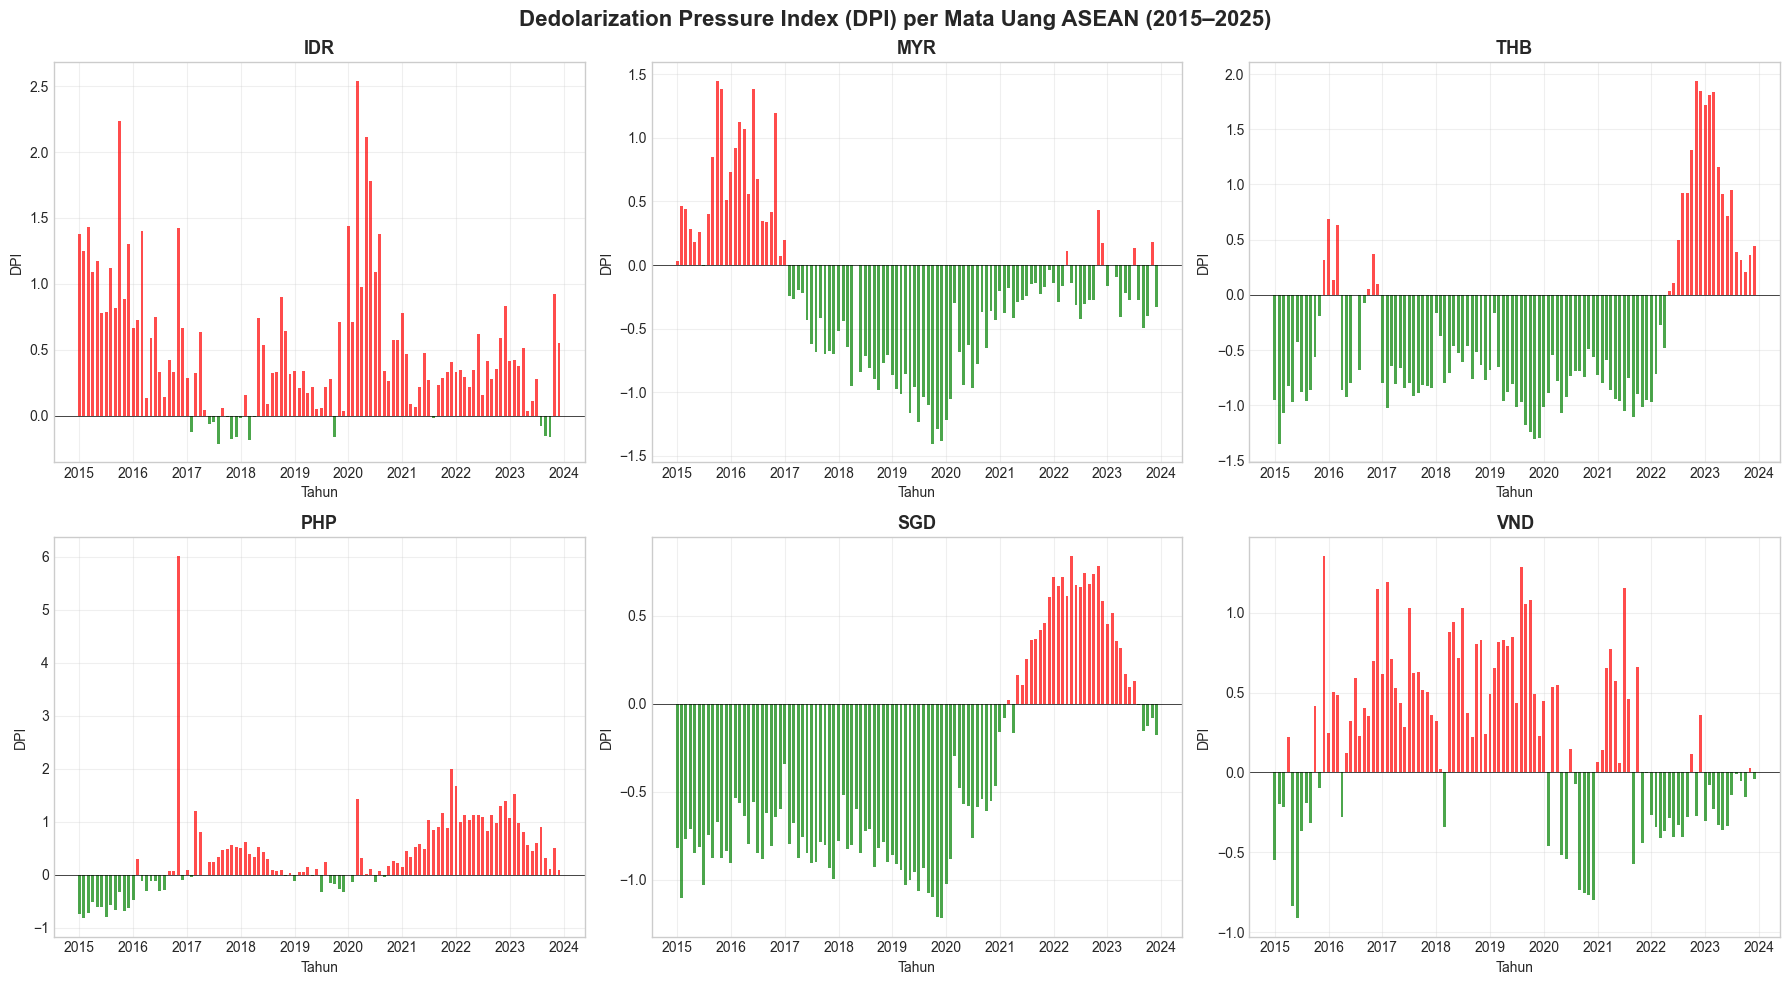


=== 5 Periode DPI Tertinggi (Tekanan Dedolarisasi Maksimum) ===


,Label,Currency,Year,Month,DPI,Volatility,Inflation
418,PHP_2016_11,PHP,2016,11,6.024571,0.601592,2.607113
62,IDR_2020_03,IDR,2020,3,2.541915,0.308311,1.836815
9,IDR_2015_10,IDR,2015,10,2.236411,0.220955,4.180570
64,IDR_2020_05,IDR,2020,5,2.110747,0.270979,1.781467
479,PHP_2021_12,PHP,2021,12,1.995281,0.161079,5.675468



=== 5 Periode DPI Terendah (Stabilitas Maksimum) ===


,Label,Currency,Year,Month,DPI,Volatility,Inflation
189,MYR_2019_10,MYR,2019,10,-1.402178,0.019300,-0.722950
191,MYR_2019_12,MYR,2019,12,-1.382234,0.028176,-1.000118
265,THB_2015_02,THB,2015,2,-1.345982,0.024606,-0.732952
322,THB_2019_11,THB,2019,11,-1.302748,0.025274,-0.607065
323,THB_2019_12,THB,2019,12,-1.298321,0.028724,-0.726501


In [ ]:
# --- Dedolarization Pressure Index (DPI) ---
# Composite index dari Volatility (z-score) + Inflation (z-score)
# Semakin tinggi DPI, semakin besar tekanan dedolarisasi

# Hitung z-score Volatility dan Inflation
vol_z = (df_agg['Volatility'] - df_agg['Volatility'].mean()) / df_agg['Volatility'].std()
inf_z = (df_agg['Inflation'] - df_agg['Inflation'].mean()) / df_agg['Inflation'].std()

# DPI = rata-rata kedua z-score
df_agg['DPI'] = (vol_z + inf_z) / 2

print("=== Statistik DPI ===")
print(df_agg['DPI'].describe().round(4))

# Visualisasi DPI per mata uang dari waktu ke waktu
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Dedolarization Pressure Index (DPI) per Mata Uang ASEAN (2015–2025)',
             fontsize=16, fontweight='bold')

for i, currency in enumerate(tickers.keys()):
    ax = axes[i // 3][i % 3]
    subset = df_agg[df_agg['Currency'] == currency].copy()
    subset['Date'] = pd.to_datetime(subset['Year'].astype(str) + '-' + subset['Month'].astype(str) + '-01')
    
    # Warna: merah jika DPI > 0 (tekanan tinggi), hijau jika DPI < 0 (stabil)
    colors = ['red' if dpi > 0 else 'green' for dpi in subset['DPI']]
    ax.bar(subset['Date'], subset['DPI'], color=colors, alpha=0.7, width=20)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_title(currency, fontweight='bold', fontsize=13)
    ax.set_xlabel('Tahun')
    ax.set_ylabel('DPI')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Identifikasi periode DPI tertinggi (tekanan dedolarisasi terbesar)
print("\n=== 5 Periode DPI Tertinggi (Tekanan Dedolarisasi Maksimum) ===")
display(df_agg.nlargest(5, 'DPI')[['Label', 'Currency', 'Year', 'Month', 'DPI', 'Volatility', 'Inflation']])

print("\n=== 5 Periode DPI Terendah (Stabilitas Maksimum) ===")
display(df_agg.nsmallest(5, 'DPI')[['Label', 'Currency', 'Year', 'Month', 'DPI', 'Volatility', 'Inflation']])


## 4. Exploratory Data Analysis (EDA)

Sesuai fase **Data Understanding** pada CRISP-DM, EDA dilakukan pada data mentah (sebelum normalisasi) untuk memahami distribusi, pola, korelasi antar fitur bulanan, serta mengidentifikasi potensi outlier.


In [32]:
# 4.0 Cek missing value data kurs harian (sebelum ffill) — justifikasi preprocessing
print("=== Missing Value Data Kurs Harian (sebelum ffill) ===")
print(df_kurs.isnull().sum())
print(f"\nTotal missing: {df_kurs.isnull().sum().sum()} dari {df_kurs.shape[0] * df_kurs.shape[1]} sel")


=== Missing Value Data Kurs Harian (sebelum ffill) ===
Ticker
IDR    2
MYR    1
PHP    2
SGD    2
THB    2
VND    0
dtype: int64

Total missing: 9 dari 17190 sel


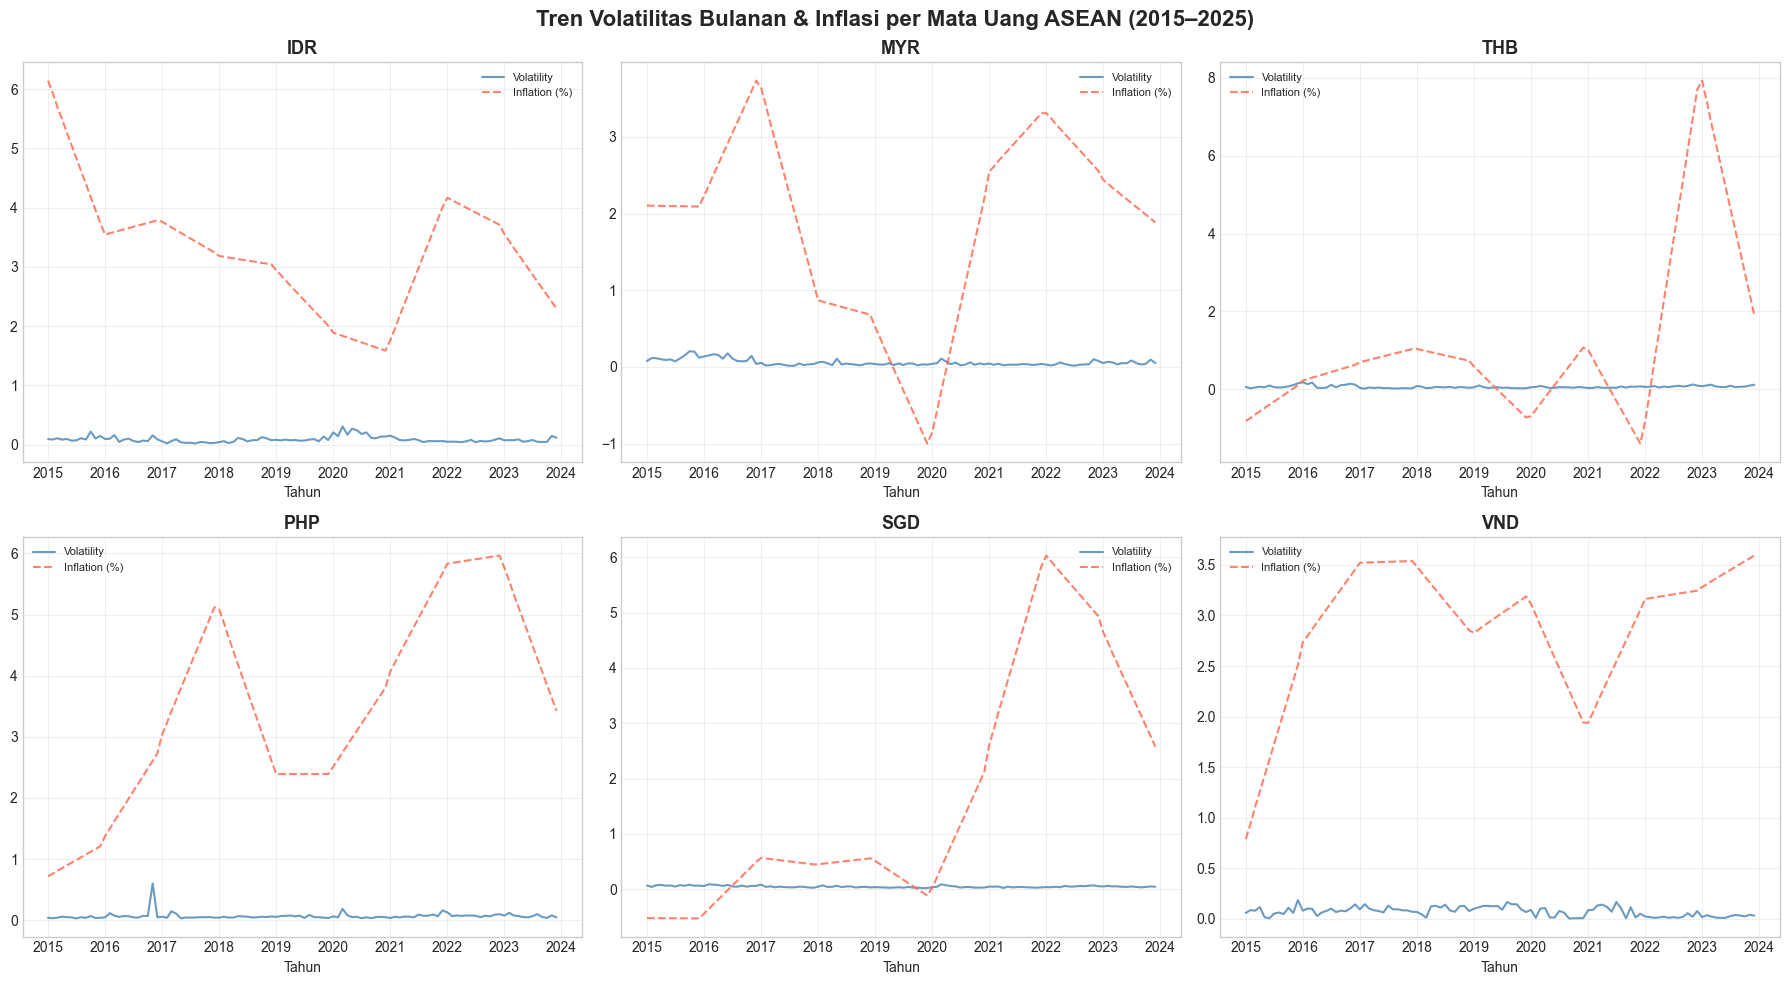

In [33]:
# 4.1 Tren Volatilitas & Inflasi per Mata Uang (Time Series Bulanan)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Tren Volatilitas Bulanan & Inflasi per Mata Uang ASEAN (2015–2025)',
             fontsize=16, fontweight='bold')

for i, currency in enumerate(tickers.keys()):
    ax = axes[i // 3][i % 3]
    subset = df_agg[df_agg['Currency'] == currency]
    # Membuat index runtun waktu bulanan untuk visualisasi yang halus
    subset['Date'] = pd.to_datetime(subset['Year'].astype(str) + '-' + subset['Month'].astype(str) + '-01')
    
    ax.plot(subset['Date'], subset['Volatility'], label='Volatility', color='steelblue', alpha=0.8)
    ax.plot(subset['Date'], subset['Inflation'], linestyle='--', label='Inflation (%)', color='tomato', alpha=0.8)
    ax.set_title(currency, fontweight='bold', fontsize=13)
    ax.set_xlabel('Tahun')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


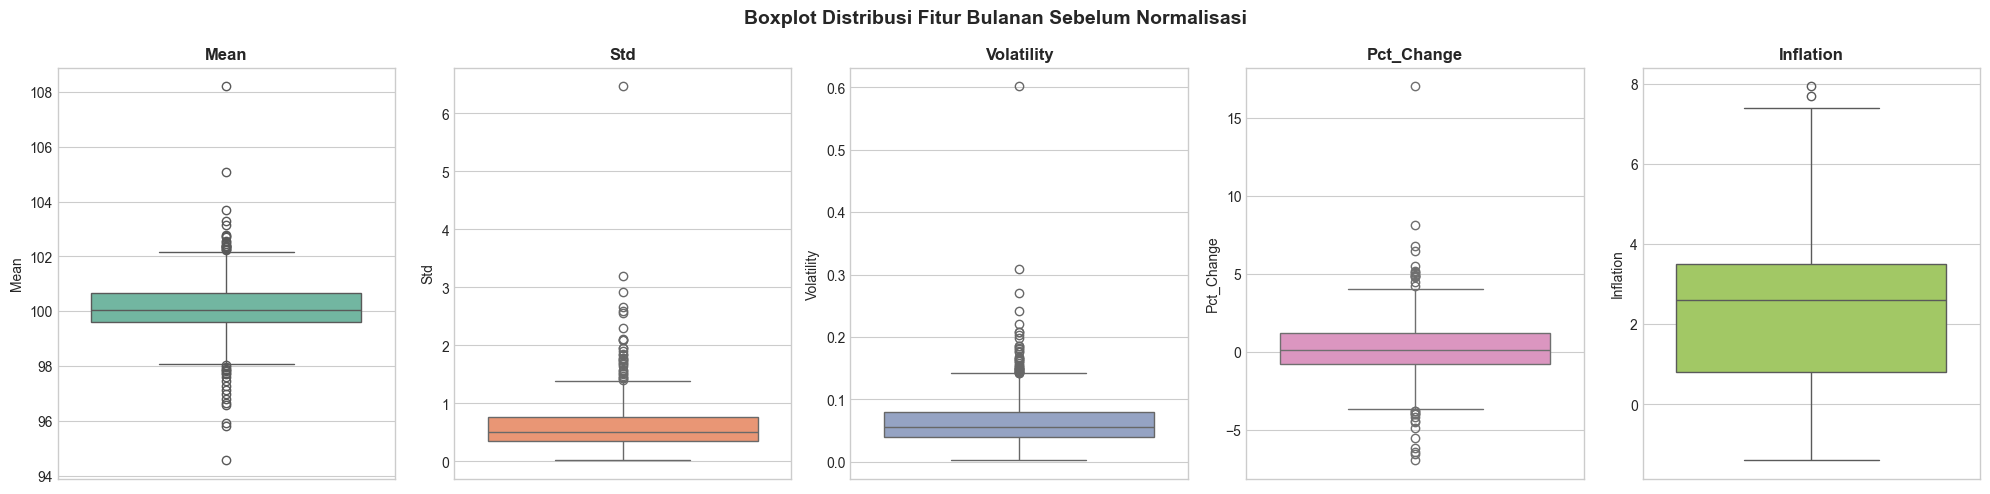

In [34]:
# 4.2 Boxplot distribusi 5 fitur (sebelum normalisasi)
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Boxplot Distribusi Fitur Bulanan Sebelum Normalisasi', fontsize=14, fontweight='bold')

for i, feat in enumerate(['Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation']):
    sns.boxplot(y=df_agg[feat], color=sns.color_palette('Set2')[i], ax=axes[i])
    axes[i].set_title(feat, fontweight='bold')

plt.tight_layout()
plt.show()


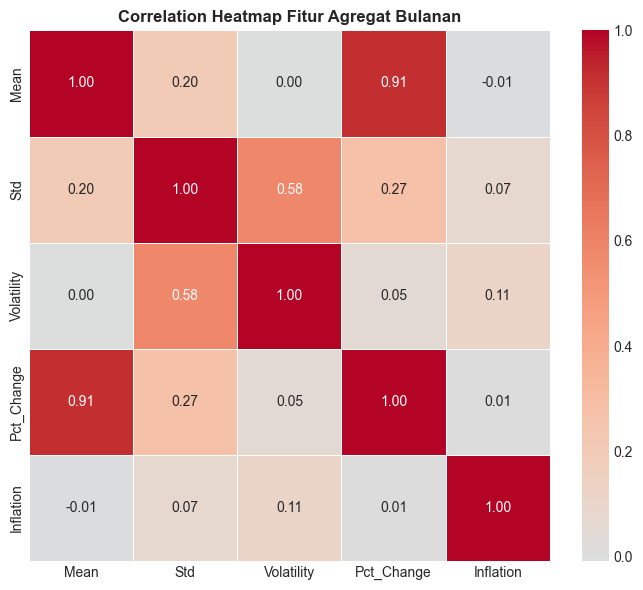

In [35]:
# 4.3 Correlation Heatmap antar fitur bulanan
plt.figure(figsize=(7, 6))
sns.heatmap(
    df_agg[['Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation']].corr(),
    annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5
)
plt.title('Correlation Heatmap Fitur Agregat Bulanan', fontweight='bold')
plt.tight_layout()
plt.show()


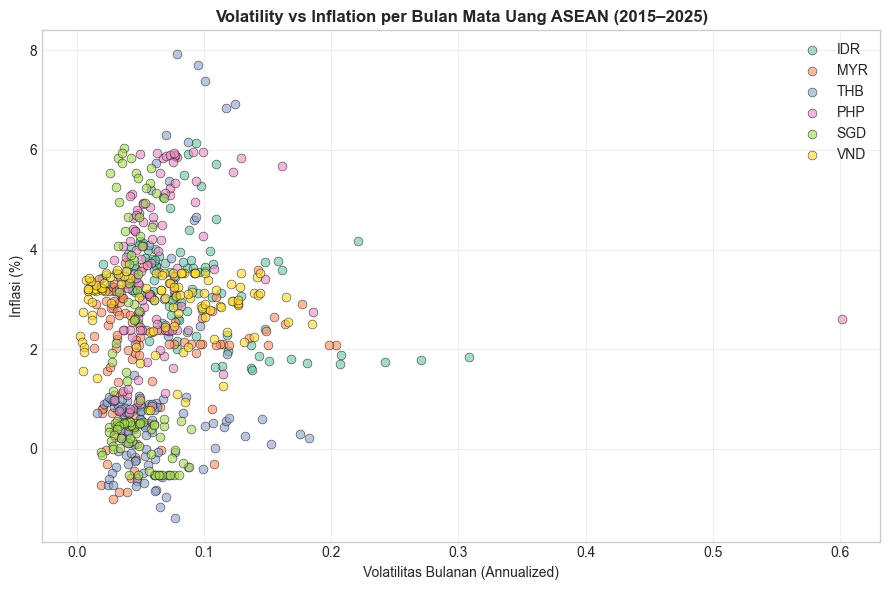

In [36]:
# 4.4 Scatter Volatility vs Inflation
plt.figure(figsize=(9, 6))
for currency in tickers.keys():
    subset = df_agg[df_agg['Currency'] == currency]
    plt.scatter(subset['Volatility'], subset['Inflation'],
                label=currency, s=40, alpha=0.6, edgecolors='black', linewidths=0.5)

plt.xlabel('Volatilitas Bulanan (Annualized)')
plt.ylabel('Inflasi (%)')
plt.title('Volatility vs Inflation per Bulan Mata Uang ASEAN (2015–2025)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [37]:
# 4.5 Statistik deskriptif & cek missing value
print("=== Statistik Deskriptif Fitur Agregat Bulanan ===")
display(df_agg[['Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation']].describe().round(4))

print("\nMissing Values setelah ffill+bfill:")
print(df_agg[['Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation']].isnull().sum())


=== Statistik Deskriptif Fitur Agregat Bulanan ===


,Mean,Std,Volatility,Pct_Change,Inflation
count,648.0000,648.0000,648.0000,648.0000,648.0000
mean,100.1116,0.6286,0.0657,0.2202,2.3902
std,1.0849,0.4714,0.0449,1.8854,1.7580
min,94.5643,0.0237,0.0026,-6.9443,-1.3921
25%,99.6157,0.3502,0.0388,-0.7880,0.8082
50%,100.0527,0.5141,0.0562,0.0965,2.5923
75%,100.6663,0.7711,0.0801,1.2104,3.4944
max,108.2115,6.4656,0.6016,16.9983,7.9310



Missing Values setelah ffill+bfill:
Mean          0
Std           0
Volatility    0
Pct_Change    0
Inflation     0
dtype: int64


---
### 4.6 Deteksi Outlier pada Data Harian Kurs (Z-Score Method)

Outlier pada data harian kurs dapat mengindikasikan hari-hari dengan guncangan ekonomi
ekstrem. Metode Z-Score digunakan untuk mendeteksi outlier: nilai dengan |Z| > 3
dianggap sebagai outlier (di luar 3 standar deviasi dari rata-rata).

**Catatan:** Pengecekan dilakukan pada **data harian sebelum agregasi bulanan**
untuk melihat fluktuasi harian yang ekstrem.


OUTLIER DETECTION PADA DATA HARIAN KURS (Z-SCORE METHOD)

IDR:
  Total data harian : 2863
  Jumlah outlier     : 0 (0.00%)

MYR:
  Total data harian : 2864
  Jumlah outlier     : 0 (0.00%)

THB:
  Total data harian : 2863
  Jumlah outlier     : 0 (0.00%)

PHP:
  Total data harian : 2863
  Jumlah outlier     : 0 (0.00%)

SGD:
  Total data harian : 2863
  Jumlah outlier     : 0 (0.00%)

VND:
  Total data harian : 2865
  Jumlah outlier     : 0 (0.00%)


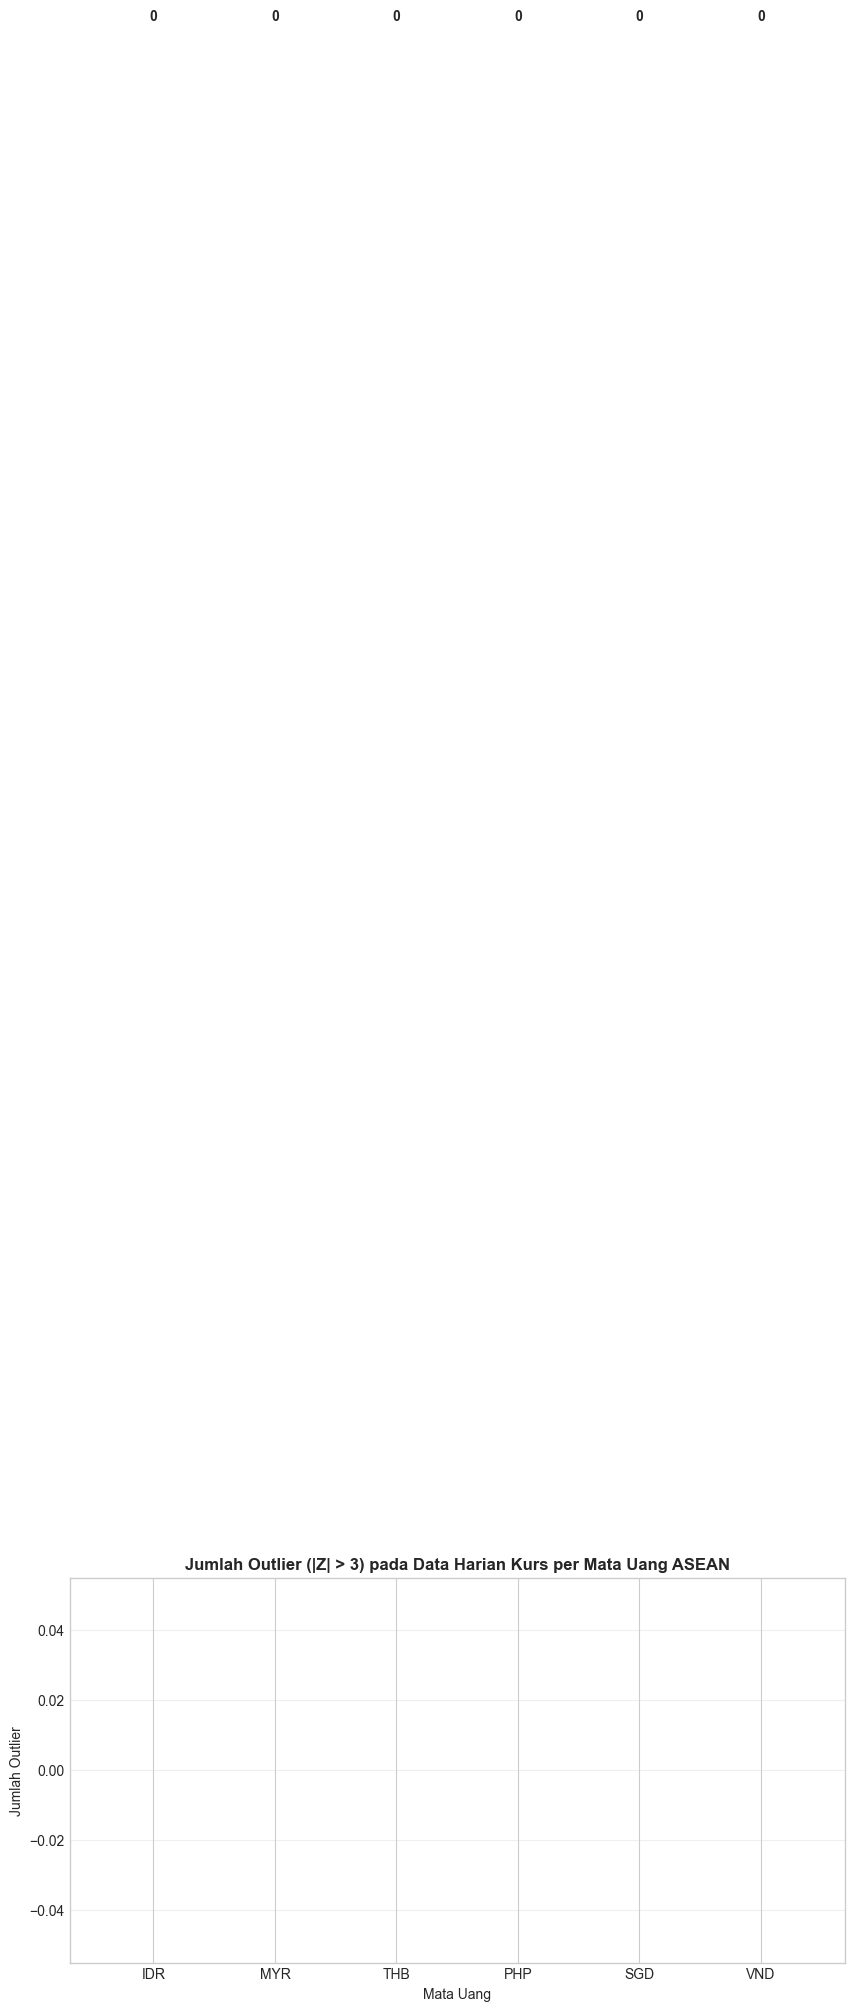


Kesimpulan: Mata uang dengan outlier terbanyak menunjukkan
fluktuasi harian yang paling ekstrem selama periode 2015-2025.


In [38]:
# === 4.6 Deteksi Outlier Z-Score pada Data Harian Kurs ===
# Gunakan data harian original sebelum agregasi (df_kurs)
print("=" * 70)
print("OUTLIER DETECTION PADA DATA HARIAN KURS (Z-SCORE METHOD)")
print("=" * 70)

zscore_outliers = {}
for currency in tickers.keys():
    prices = df_kurs[currency].dropna()
    # Hitung z-score
    mean_p = prices.mean()
    std_p = prices.std()
    z_scores = (prices - mean_p) / std_p
    
    # Tandai outlier (|z| > 3)
    outlier_mask = abs(z_scores) > 3
    n_outliers = outlier_mask.sum()
    pct_outliers = (n_outliers / len(prices)) * 100
    
    zscore_outliers[currency] = {
        'n_outliers': n_outliers,
        'pct_outliers': pct_outliers,
        'dates': prices[outlier_mask].index.tolist()
    }
    
    print(f"\n{currency}:")
    print(f"  Total data harian : {len(prices)}")
    print(f"  Jumlah outlier     : {n_outliers} ({pct_outliers:.2f}%)")
    if n_outliers > 0:
        print(f"  Tanggal outlier    : {prices[outlier_mask].index[:5].tolist()}...")
        print(f"  Nilai outlier      : {prices[outlier_mask].values[:5]}...")

# Bar chart jumlah outlier per currency
plt.figure(figsize=(10, 5))
currencies_list = list(tickers.keys())
outlier_counts = [zscore_outliers[c]['n_outliers'] for c in currencies_list]

bars = plt.bar(currencies_list, outlier_counts, color=['green', 'orange', 'red', 'blue', 'purple', 'brown'])
for bar, count in zip(bars, outlier_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha='center', fontweight='bold')

plt.title('Jumlah Outlier (|Z| > 3) pada Data Harian Kurs per Mata Uang ASEAN', fontweight='bold')
plt.xlabel('Mata Uang')
plt.ylabel('Jumlah Outlier')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nKesimpulan: Mata uang dengan outlier terbanyak menunjukkan")
print("fluktuasi harian yang paling ekstrem selama periode 2015-2025.")


---
### 4.7 Distribusi Return Harian (Log-Return)

Return harian dihitung sebagai log-return: r_t = ln(P_t / P_{t-1})
Distribusi return harian memberikan gambaran tentang:
- **Volatilitas**: semakin lebar distribusi, semakin volatil mata uang
- **Skewness**: kecenderungan depresiasi (negatif) atau apresiasi (positif)
- **Kurtosis**: frekuensi kejutan ekstrem (fat tails)


DISTRIBUSI RETURN HARIAN (LOG-RETURN) PER MATA UANG ASEAN


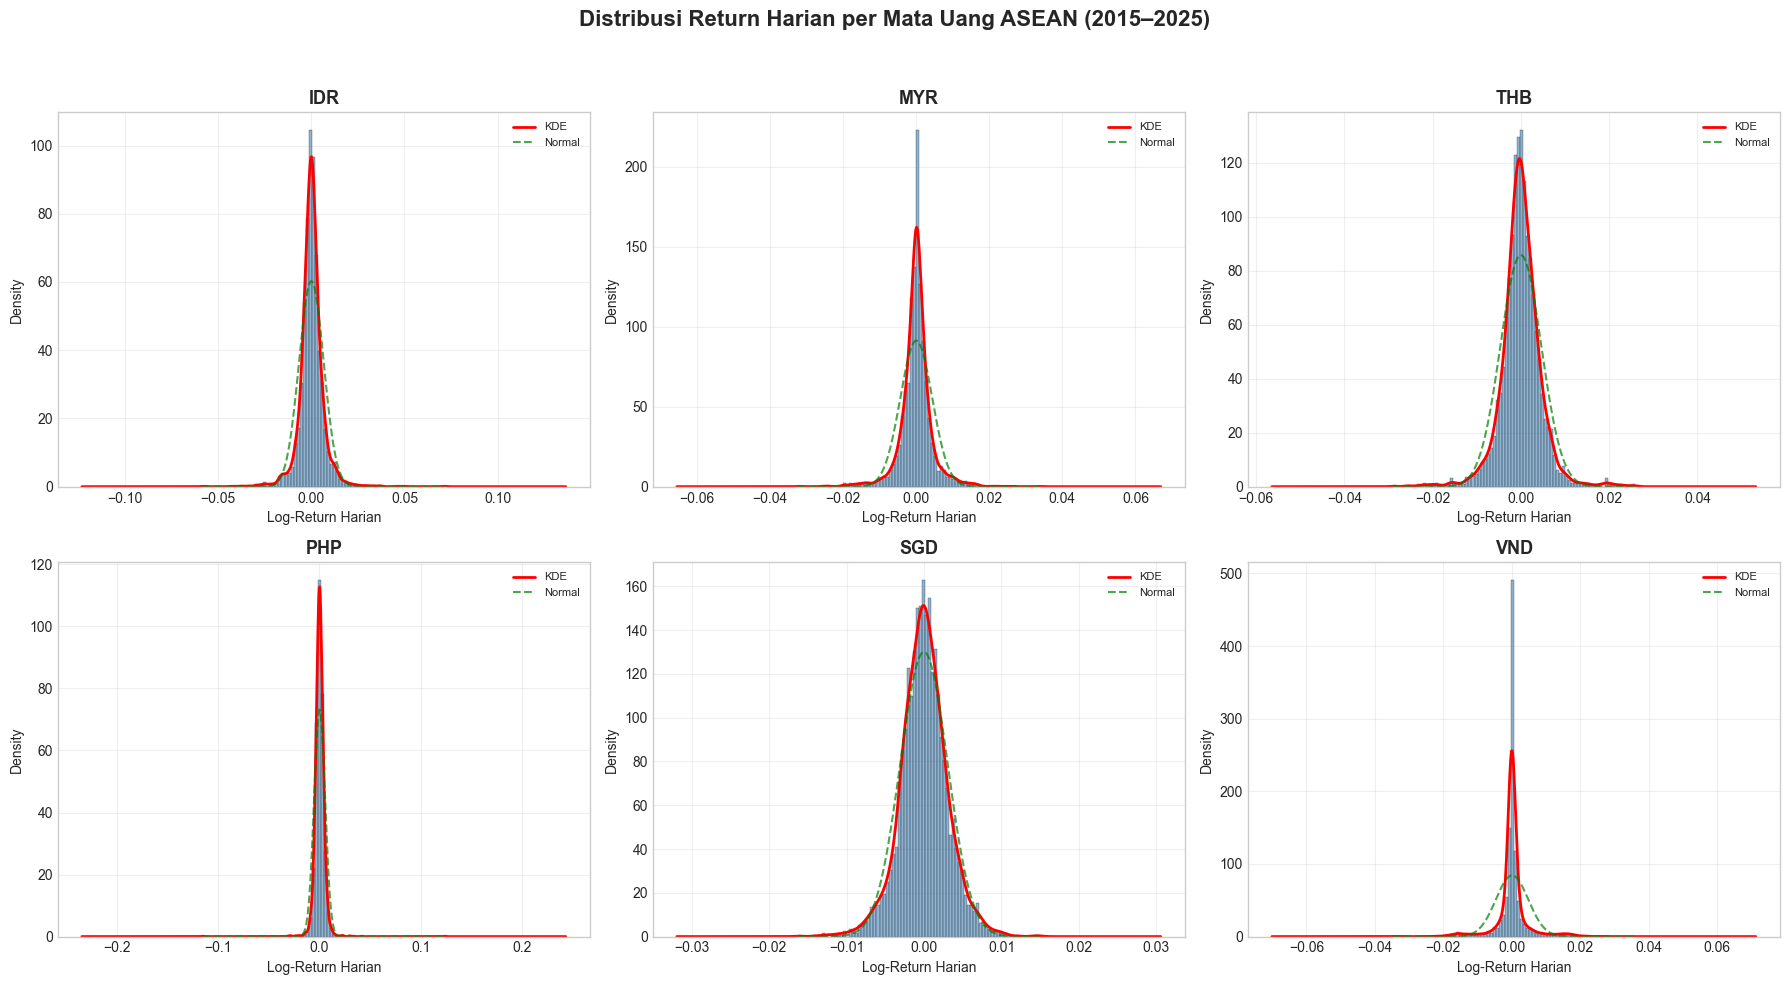


=== Statistik Return Harian per Mata Uang ===


,Currency,Mean,Std,Skewness,Excess Kurtosis,Annualized Vol,Min,Max
0,IDR,0.000104,0.0066,0.2769,13.3696,0.1050,-0.0581,0.0717
1,MYR,0.000051,0.0044,-0.1420,7.4662,0.0693,-0.0323,0.0338
2,THB,-0.000015,0.0046,0.0185,5.6705,0.0738,-0.0290,0.0258
3,PHP,0.000097,0.0055,0.8922,165.3550,0.0865,-0.1152,0.1237
4,SGD,-0.000011,0.0031,-0.0804,1.7148,0.0487,-0.0163,0.0150
5,VND,0.000071,0.0047,0.0887,10.2931,0.0752,-0.0348,0.0359


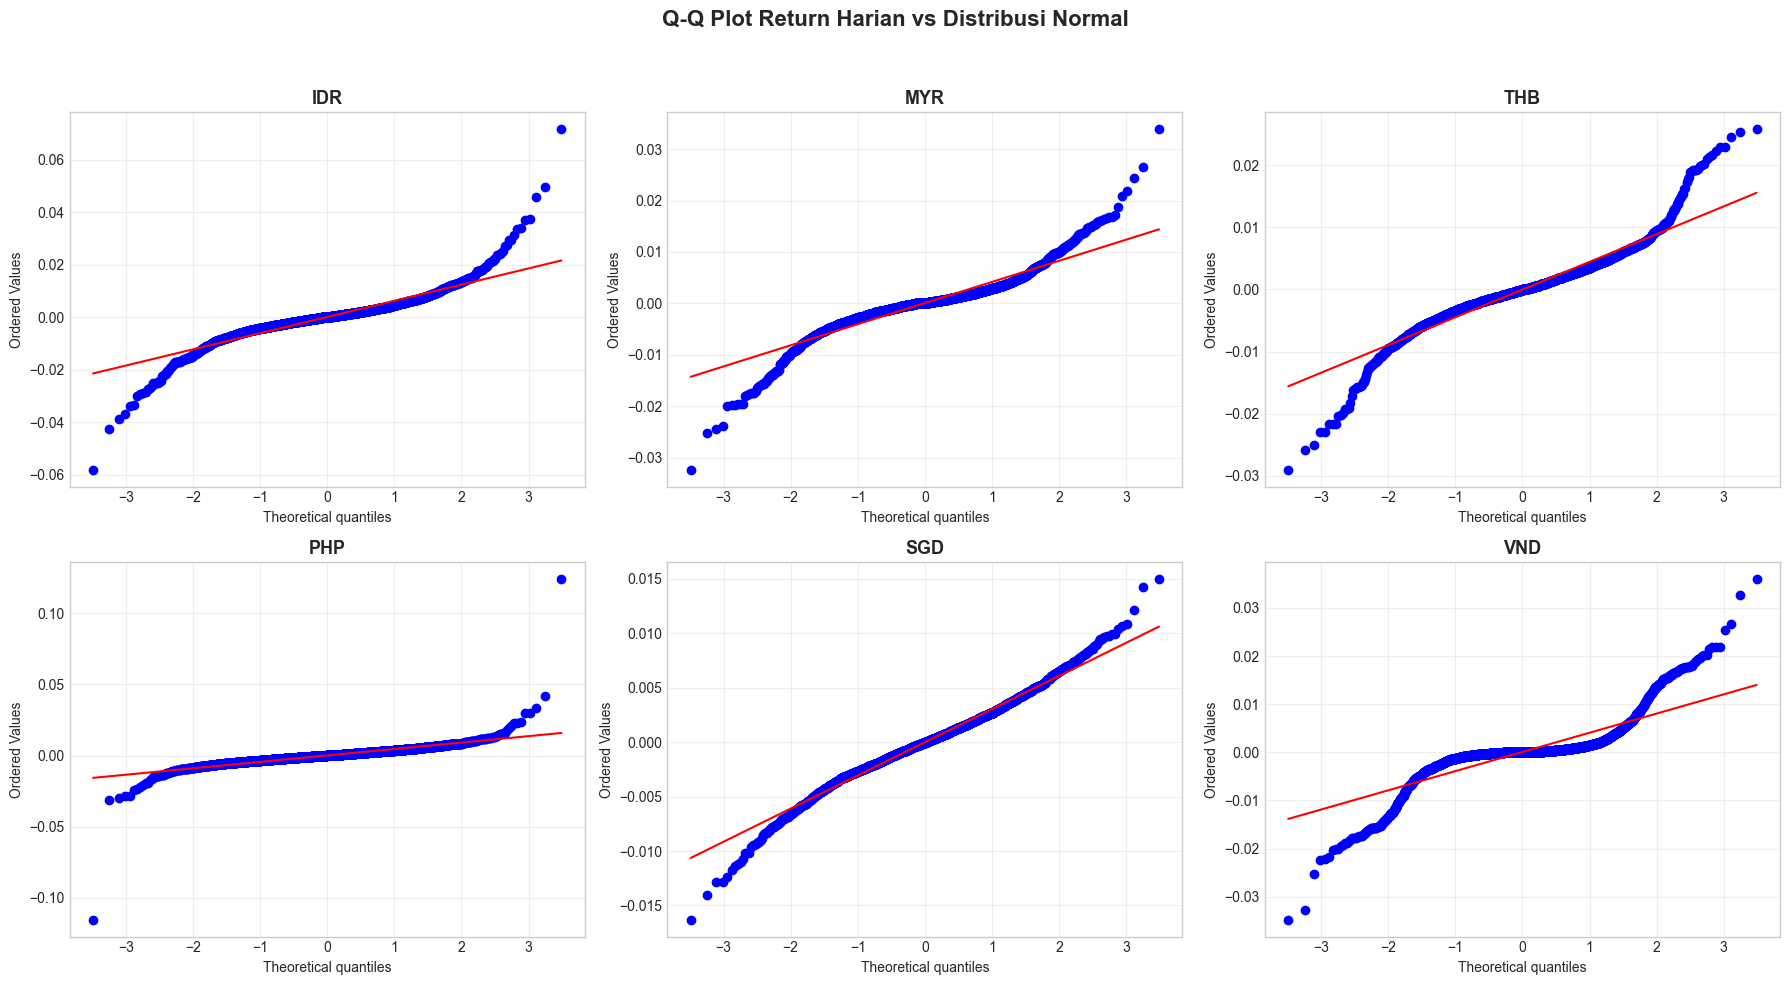


Interpretasi:
- Excess Kurtosis > 0: distribusi memiliki 'fat tails' (risiko ekstrem lebih tinggi)
- Skewness negatif: kecenderungan depresiasi (return negatif) lebih sering
- Jika Q-Q plot menyimpang dari garis diagonal, return tidak terdistribusi normal


In [39]:
# === 4.7 Distribusi Return Harian Log-Return ===
print("=" * 70)
print("DISTRIBUSI RETURN HARIAN (LOG-RETURN) PER MATA UANG ASEAN")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribusi Return Harian per Mata Uang ASEAN (2015\u20132025)',
             fontsize=16, fontweight='bold')

return_stats = []
for i, currency in enumerate(tickers.keys()):
    ax = axes[i // 3][i % 3]
    prices = df_kurs[currency].dropna()
    log_returns = np.log(prices / prices.shift(1)).dropna()
    
    # Histogram + KDE
    ax.hist(log_returns, bins=80, density=True, alpha=0.6,
            color='steelblue', edgecolor='black', linewidth=0.3)
    log_returns.plot.kde(ax=ax, color='red', linewidth=2, label='KDE')
    
    # Overlay normal distribution for comparison
    mu = log_returns.mean()
    sigma = log_returns.std()
    x_range = np.linspace(log_returns.min(), log_returns.max(), 200)
    normal_pdf = (1 / (sigma * np.sqrt(2 * np.pi)) *
                  np.exp(-(x_range - mu)**2 / (2 * sigma**2)))
    ax.plot(x_range, normal_pdf, 'g--', linewidth=1.5, alpha=0.7, label='Normal')
    
    ax.set_title(currency, fontweight='bold', fontsize=13)
    ax.set_xlabel('Log-Return Harian')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Statistics
    skewness = log_returns.skew()
    kurtosis = log_returns.kurtosis()  # excess kurtosis
    annualized_vol = log_returns.std() * np.sqrt(252)
    
    return_stats.append({
        'Currency': currency,
        'Mean': f'{mu:.6f}',
        'Std': f'{sigma:.4f}',
        'Skewness': f'{skewness:.4f}',
        'Excess Kurtosis': f'{kurtosis:.4f}',
        'Annualized Vol': f'{annualized_vol:.4f}',
        'Min': f'{log_returns.min():.4f}',
        'Max': f'{log_returns.max():.4f}'
    })

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Tabel statistik return
df_return_stats = pd.DataFrame(return_stats)
print("\n=== Statistik Return Harian per Mata Uang ===")
display(df_return_stats)

# QQ-Plot untuk perbandingan dengan distribusi normal
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Q-Q Plot Return Harian vs Distribusi Normal',
             fontsize=16, fontweight='bold')

from scipy import stats as scipy_stats
for i, currency in enumerate(tickers.keys()):
    ax = axes[i // 3][i % 3]
    prices = df_kurs[currency].dropna()
    log_returns = np.log(prices / prices.shift(1)).dropna()
    
    scipy_stats.probplot(log_returns, dist='norm', plot=ax)
    ax.set_title(currency, fontweight='bold', fontsize=13)
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\nInterpretasi:")
print("- Excess Kurtosis > 0: distribusi memiliki 'fat tails' (risiko ekstrem lebih tinggi)")
print("- Skewness negatif: kecenderungan depresiasi (return negatif) lebih sering")
print("- Jika Q-Q plot menyimpang dari garis diagonal, return tidak terdistribusi normal")


## 5. Preprocessing Lanjutan: Normalisasi & Reduksi Dimensi

Karena skala fitur sangat berbeda (misalnya `Mean` IDR bernilai ribuan vs `Inflation` bernilai satuan persen), **Z-Score Normalization** wajib diterapkan sebelum clustering agar tidak ada fitur yang mendominasi perhitungan jarak Euclidean (Bab 2.3.3).

**PCA 2 komponen** digunakan semata untuk keperluan **visualisasi** hasil clustering, bukan sebagai input model (Bab 2.3.4).


In [40]:
# 5.1 Z-Score Normalization
features = ['Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation']
X = df_agg[features].values

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Normalisasi selesai. Mean ≈ 0, Std ≈ 1 untuk setiap fitur.")

# 5.2 PCA 2D untuk visualisasi
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_agg['PCA1'] = X_pca[:, 0]
df_agg['PCA2'] = X_pca[:, 1]

print(f"Variance yang dipertahankan 2 komponen PCA: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")


Normalisasi selesai. Mean ≈ 0, Std ≈ 1 untuk setiap fitur.
Variance yang dipertahankan 2 komponen PCA: 71.25%
  PC1: 41.67%
  PC2: 29.58%


---
## Fase 4: Modeling (CRISP-DM) — 3.5

Menerapkan empat algoritma clustering:
1. **K-Means** — Partitioning-based, minimisasi WCSS
2. **DBSCAN** — Density-based, deteksi noise/anomali
3. **Agglomerative Hierarchical Clustering** — Hierarchical, Ward linkage
4. **K-Medoids (PAM)** — Partitioning-based, robust terhadap outlier

### Justifikasi Pemilihan k=3

Berdasarkan hasil Elbow Method, knee terdeteksi pada **k=5**, namun Silhouette Score menunjukkan **k=3** sebagai optimal (skor tertinggi).

Pemilihan **k=3** didasarkan pada **interpretabilitas ekonomi**:
- Literatur stabilitas nilai tukar kawasan ASEAN mengategorikan kondisi mata uang ke dalam tiga rezim: stabil, moderat, dan rentan (Ogawa & Luo, 2025).
- Tiga klaster memungkinkan pemetaan langsung ke kebijakan: **A=Stable** (intervensi minimal), **B=Moderate** (waspada), **C=Vulnerable** (intervensi aktif).
- Jumlah klaster ganjil (k=3) menghindari ambiguitas kategorisasi biner dan memberikan titik tengah (moderate) untuk transisi kebijakan.

Dengan demikian, k=3 dipilih sebagai **keseimbangan antara optimalitas statistik dan relevansi kebijakan**.


## 6. Modeling

Menerapkan empat algoritma clustering sesuai Bab 2.1: **K-Means**, **DBSCAN**, **Agglomerative Hierarchical Clustering (AHC)**, dan **K-Medoids**.


### 6.1 K-Means Clustering

K-Means meminimalkan **Within-Cluster Sum of Squares (WCSS/SSE)**. Nilai `k` optimal ditentukan menggunakan:
- **Elbow Method** dengan deteksi otomatis via `KneeLocator`
- **Silhouette Score** sebagai verifikasi kuantitatif

Berdasarkan justifikasi di Fase 4, k=3 ditetapkan sebagai jumlah klaster final.


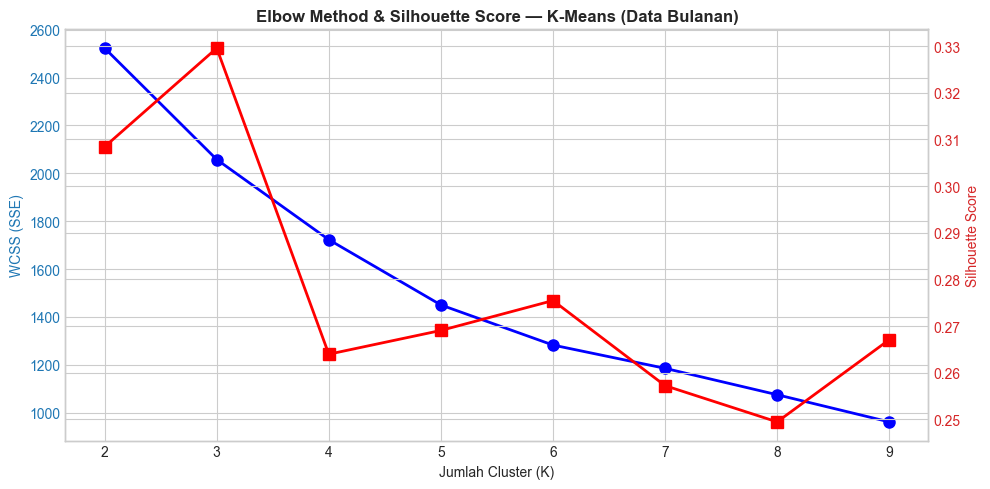

K optimal (KneeLocator/Elbow) : 5
K optimal (Silhouette Score)  : 3
K final yang digunakan        : 3

Distribusi cluster K-Means:
KMeans_Cluster
0     60
1    454
2    134
Name: count, dtype: int64


In [41]:
wcss = []
silhouette_scores_km = []
K_range = range(2, 10)

for k in K_range:
    km  = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    silhouette_scores_km.append(silhouette_score(X_scaled, lbl))

# Plot Elbow + Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('WCSS (SSE)', color='tab:blue')
ax1.plot(list(K_range), wcss, 'bo-', linewidth=2, markersize=8)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(list(K_range), silhouette_scores_km, 'rs-', linewidth=2, markersize=8)
ax2.tick_params(axis='y', labelcolor='tab:red')
plt.title('Elbow Method & Silhouette Score — K-Means (Data Bulanan)', fontweight='bold')
plt.tight_layout()
plt.show()

# Deteksi K optimal
knee = KneeLocator(list(K_range), wcss, curve='convex', direction='decreasing')
optimal_k_elbow = knee.elbow
optimal_k_sil   = list(K_range)[np.argmax(silhouette_scores_km)]
print(f"K optimal (KneeLocator/Elbow) : {optimal_k_elbow}")
print(f"K optimal (Silhouette Score)  : {optimal_k_sil}")

optimal_k = 3  # k=3: keseimbangan optimalitas statistik (Silhouette) & interpretabilitas ekonomi (Ogawa & Luo, 2025)
print(f"K final yang digunakan        : {optimal_k}")

# Fit K-Means final
kmeans_best = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df_agg['KMeans_Cluster'] = kmeans_best.fit_predict(X_scaled)

print("\nDistribusi cluster K-Means:")
print(df_agg['KMeans_Cluster'].value_counts().sort_index())


### 6.2 DBSCAN Clustering

DBSCAN mengelompokkan titik berdasarkan kepadatan (*density-based*) dengan dua parameter utama:
- **ε (epsilon)**: radius neighbourhood
- **MinPts**: jumlah minimum titik dalam radius ε

**K-Distance Plot** digunakan untuk mengestimasi rentang `eps` yang wajar sebelum grid search.


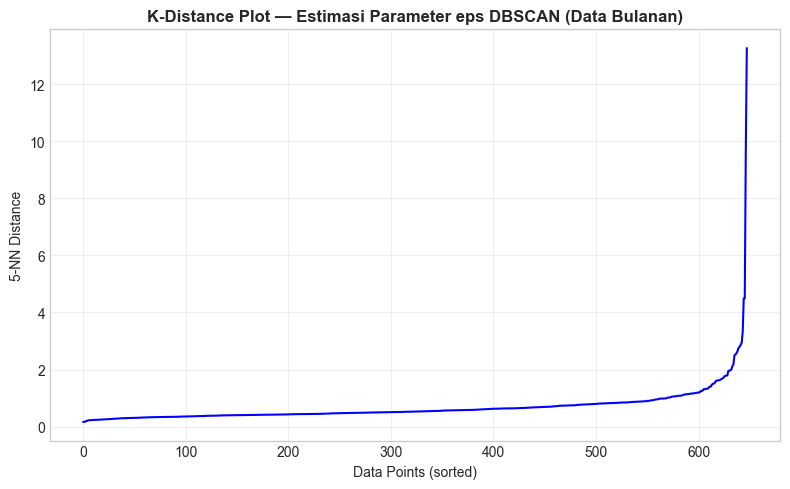

Amati titik 'elbow' pada grafik sebagai referensi batas bawah rentang eps grid search.


In [42]:
# K-Distance Plot untuk estimasi eps
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(distances, 'b-', linewidth=1.5)
plt.xlabel('Data Points (sorted)')
plt.ylabel('5-NN Distance')
plt.title('K-Distance Plot — Estimasi Parameter eps DBSCAN (Data Bulanan)', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Amati titik 'elbow' pada grafik sebagai referensi batas bawah rentang eps grid search.")


In [43]:
# Grid search parameter DBSCAN
eps_values         = np.arange(0.3, 3.0, 0.1)
min_samples_values = range(2, 6)

best_eps, best_min_samples, best_silhouette, best_labels = -1, -1, -1, []

for eps in eps_values:
    for min_pts in min_samples_values:
        lbl  = DBSCAN(eps=eps, min_samples=min_pts).fit_predict(X_scaled)
        n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
        if n_cl > 1:
            mask = lbl != -1
            if mask.sum() > 1:
                score = silhouette_score(X_scaled[mask], lbl[mask])
                if score > best_silhouette:
                    best_silhouette  = score
                    best_eps         = eps
                    best_min_samples = min_pts
                    best_labels      = lbl

if best_eps == -1:
    print("Grid search gagal menemukan klaster valid, menggunakan parameter default.")
    best_eps, best_min_samples = 1.0, 3
    best_labels = DBSCAN(eps=best_eps, min_samples=best_min_samples).fit_predict(X_scaled)

df_agg['DBSCAN_Cluster'] = np.array(best_labels)
n_noise = (best_labels == -1).sum()
n_cl    = len(set(best_labels)) - (1 if -1 in best_labels else 0)

print(f"Parameter terbaik : eps={best_eps:.2f}, min_samples={best_min_samples}")
print(f"Jumlah cluster    : {n_cl}")
print(f"Noise points      : {n_noise} dari {len(df_agg)} data")
if n_noise > 0:
    print("\nSample observasi terdeteksi sebagai noise (anomali) - Tampilkan 10 data pertama:")
    display(df_agg[df_agg['DBSCAN_Cluster'] == -1][['Label', 'Volatility', 'Inflation']].head(10))


Parameter terbaik : eps=2.40, min_samples=2
Jumlah cluster    : 2
Noise points      : 3 dari 648 data

Sample observasi terdeteksi sebagai noise (anomali) - Tampilkan 10 data pertama:


,Label,Volatility,Inflation
9,IDR_2015_10,0.220955,4.180570
62,IDR_2020_03,0.308311,1.836815
418,PHP_2016_11,0.601592,2.607113


### 6.3 Agglomerative Hierarchical Clustering (AHC)

Pendekatan *bottom-up*: setiap observasi dimulai sebagai klaster jangka pendek lalu digabungkan secara bertahap. Menggunakan **Ward's Linkage** yang meminimalkan peningkatan WCSS saat penggabungan.


In [44]:
# Fit AHC dengan k=3
ahc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df_agg['AHC_Cluster'] = ahc.fit_predict(X_scaled)

print("Distribusi cluster AHC (n_clusters=3):")
print(df_agg['AHC_Cluster'].value_counts().sort_index())


Distribusi cluster AHC (n_clusters=3):
AHC_Cluster
0    549
1     57
2     42
Name: count, dtype: int64


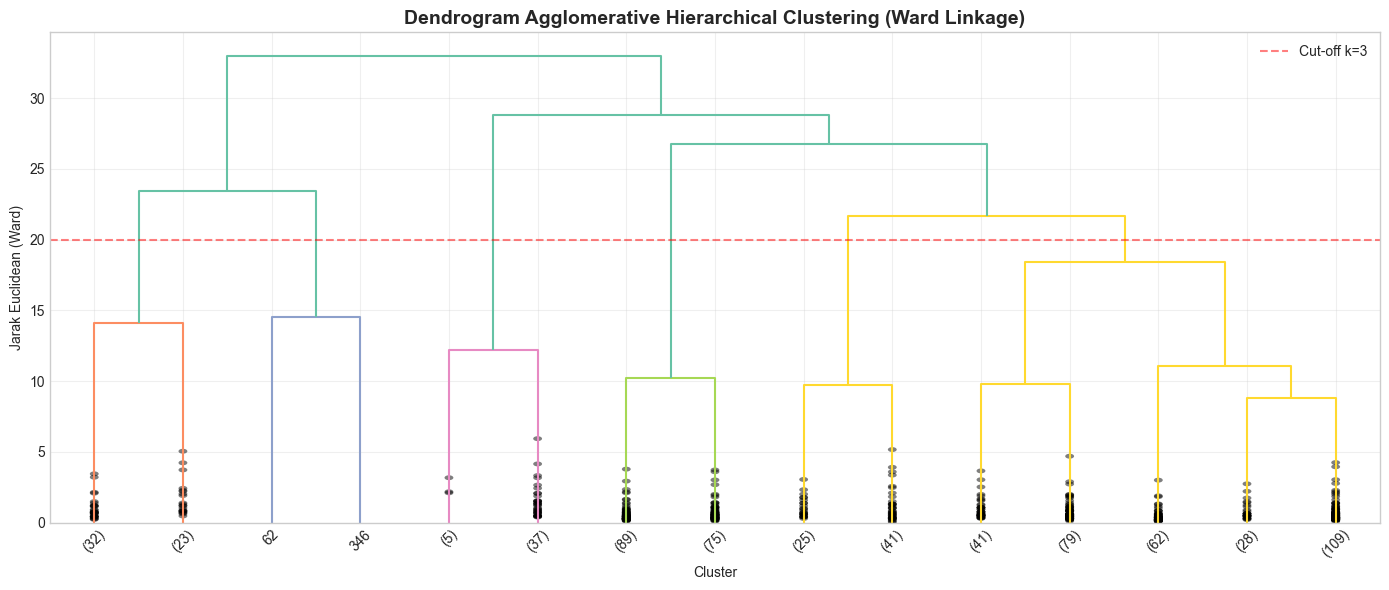


Cluster assignments (via fcluster, k=3): [1 2 3]
Distribusi: {1: 57, 2: 42, 3: 549}


In [45]:
# --- Dendrogram untuk AHC ---
plt.figure(figsize=(14, 6))
Z = sch.linkage(X_scaled, method='ward')
dn = sch.dendrogram(Z, truncate_mode='lastp', p=15,
                    leaf_rotation=45., leaf_font_size=10.,
                    show_contracted=True)
plt.title('Dendrogram Agglomerative Hierarchical Clustering (Ward Linkage)',
          fontweight='bold', fontsize=14)
plt.xlabel('Cluster')
plt.ylabel('Jarak Euclidean (Ward)')
plt.axhline(y=20, color='red', linestyle='--', alpha=0.5,
            label='Cut-off k=3')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Warn cluster membership pada dendrogram
from scipy.cluster.hierarchy import fcluster
cluster_assignments = fcluster(Z, t=3, criterion='maxclust')
print(f"\nCluster assignments (via fcluster, k=3): {np.unique(cluster_assignments)}")
print(f"Distribusi: {pd.Series(cluster_assignments).value_counts().sort_index().to_dict()}")


### 6.4 K-Medoids Clustering

K-Medoids (Partitioning Around Medoids / PAM) meminimalkan disimilaritas absolut antar objek dengan memilih objek data riil (*medoid*) sebagai pusat klaster, memberikan ketahanan struktural yang lebih baik terhadap data pencilan (*outliers*) finansial.


In [46]:
# Fit K-Medoids dengan k=3
kmedoids = SimpleKMedoids(n_clusters=3, random_state=42)
df_agg['KMedoids_Cluster'] = kmedoids.fit_predict(X_scaled)

print("Distribusi cluster K-Medoids (n_clusters=3):")
print(df_agg['KMedoids_Cluster'].value_counts().sort_index())


Distribusi cluster K-Medoids (n_clusters=3):
KMedoids_Cluster
0     72
1    201
2    375
Name: count, dtype: int64


---
### 6.5 Analisis Karakteristik Klaster & Labeling Stabilitas

Setelah clustering dengan k=3, profil setiap klaster dianalisis
berdasarkan rata-rata fiturnya untuk menentukan label:
- **A – Stable**: Volatilitas rendah, inflasi rendah, Pct\_Change mendekati 0
- **B – Moderate**: Volatilitas sedang, fluktuasi wajar
- **C – Vulnerable**: Volatilitas tinggi, inflasi tinggi, tekanan depresiasi

Labeling mengacu pada karakteristik stabilitas nilai tukar ASEAN
sebagaimana diklasifikasikan oleh Ogawa & Luo (2025):
tiga rezim stabilitas yang merefleksikan tingkat kerentanan
mata uang terhadap tekanan dedolarisasi.


=== Profil Rata-rata Fitur per Cluster (K-Means, k=3) ===


,Mean,Std,Volatility,Pct_Change,Inflation,Count
KMeans_Cluster,,,,,,
0,98.3604,1.2155,0.1239,-2.6518,2.8709,60
1,99.9505,0.4319,0.0529,-0.1011,2.1875,454
2,101.4414,1.0325,0.0830,2.5947,2.8616,134


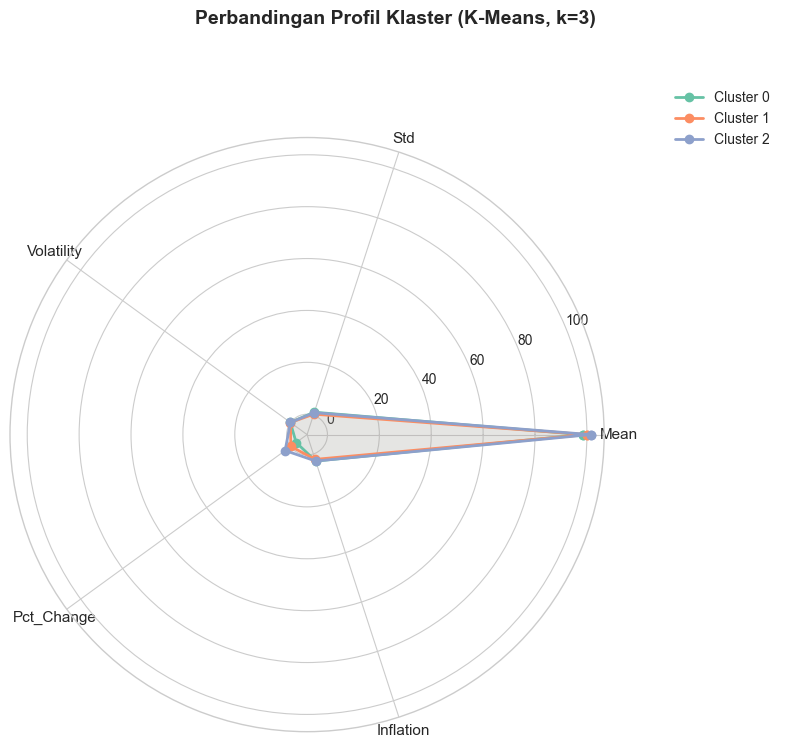


=== Mapping Cluster ke Label Stabilitas ===
  Cluster 1 -> A - Stable
  Cluster 2 -> B - Moderate
  Cluster 0 -> C - Vulnerable

=== Distribusi Label Stabilitas ===
Stability_Label
A - Stable        454
B - Moderate      134
C - Vulnerable     60
Name: count, dtype: int64


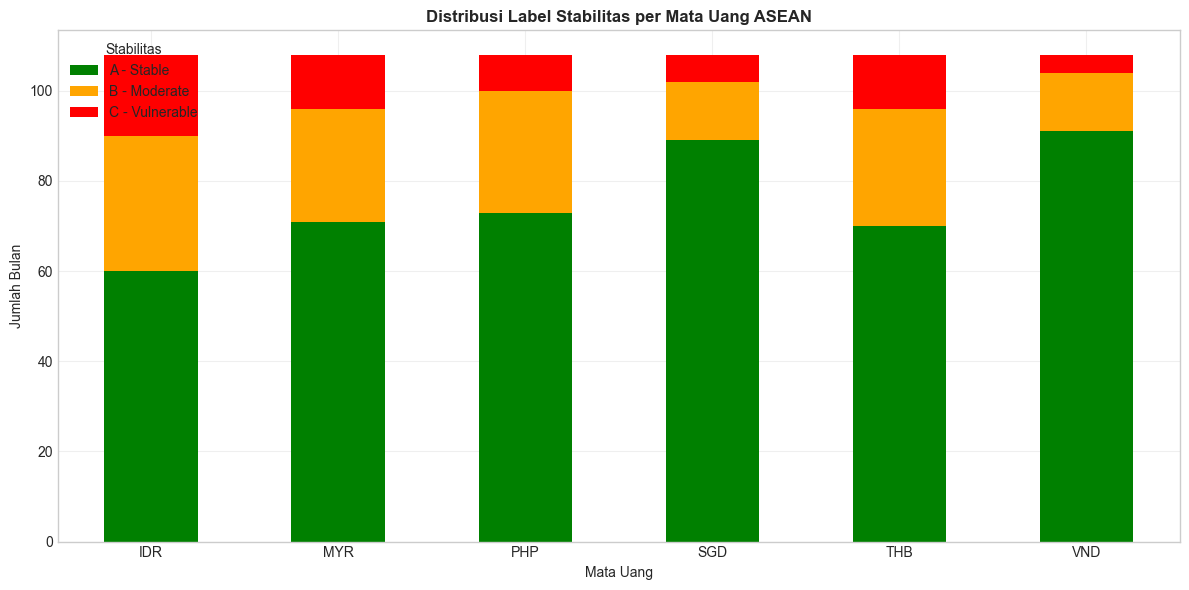

In [47]:
# === 6.5 Analisis Karakteristik Klaster & Labeling ===

# Gunakan hasil K-Means sebagai referensi labeling
features_plot = ['Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation']

# Hitung profil rata-rata per cluster
cluster_profile = df_agg.groupby('KMeans_Cluster')[features_plot].mean().round(4)
cluster_profile['Count'] = df_agg.groupby('KMeans_Cluster').size()

print("=== Profil Rata-rata Fitur per Cluster (K-Means, k=3) ===")
display(cluster_profile)

# Radar Chart per cluster
from math import pi
categories = features_plot
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle('Perbandingan Profil Klaster (K-Means, k=3)', fontsize=14, fontweight='bold')

for cluster_id in sorted(df_agg['KMeans_Cluster'].unique()):
    values = cluster_profile.loc[cluster_id, categories].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster_id}')
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

# --- Labeling otomatis A/B/C berdasarkan Volatility + Inflation ---
# Cluster dengan volatility+inflation tertinggi -> Vulnerable (C)
# Cluster dengan volatility+inflation terendah -> Stable (A)
# Sisanya -> Moderate (B)

# Hitung tekanan (volatility + inflation) per cluster
cluster_pressure = df_agg.groupby('KMeans_Cluster')[['Volatility', 'Inflation']].mean().sum(axis=1)
sorted_clusters = cluster_pressure.sort_values().index.tolist()

label_map = {
    sorted_clusters[0]: 'A - Stable',
    sorted_clusters[1]: 'B - Moderate',
    sorted_clusters[2]: 'C - Vulnerable'
}

df_agg['Stability_Label'] = df_agg['KMeans_Cluster'].map(label_map)

print("\n=== Mapping Cluster ke Label Stabilitas ===")
for k, v in label_map.items():
    print(f"  Cluster {k} -> {v}")

print("\n=== Distribusi Label Stabilitas ===")
print(df_agg['Stability_Label'].value_counts())

# Bar plot distribusi label per mata uang
plt.figure(figsize=(12, 6))
ct = pd.crosstab(df_agg['Currency'], df_agg['Stability_Label'])
ct.plot(kind='bar', stacked=True, ax=plt.gca(), color=['green', 'orange', 'red'])
plt.title('Distribusi Label Stabilitas per Mata Uang ASEAN', fontweight='bold')
plt.xlabel('Mata Uang')
plt.ylabel('Jumlah Bulan')
plt.legend(title='Stabilitas')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
### 6.6 Cluster Timeline: Pergeseran Stabilitas dari Waktu ke Waktu

Visualisasi ini menunjukkan bagaimana assignment klaster setiap mata uang
berubah dari bulan ke bulan selama periode 2015–2025.
Pergeseran antar rezim (Stable ↔ Moderate ↔ Vulnerable) dianalisis
untuk mengidentifikasi periode krisis dan pemulihan.


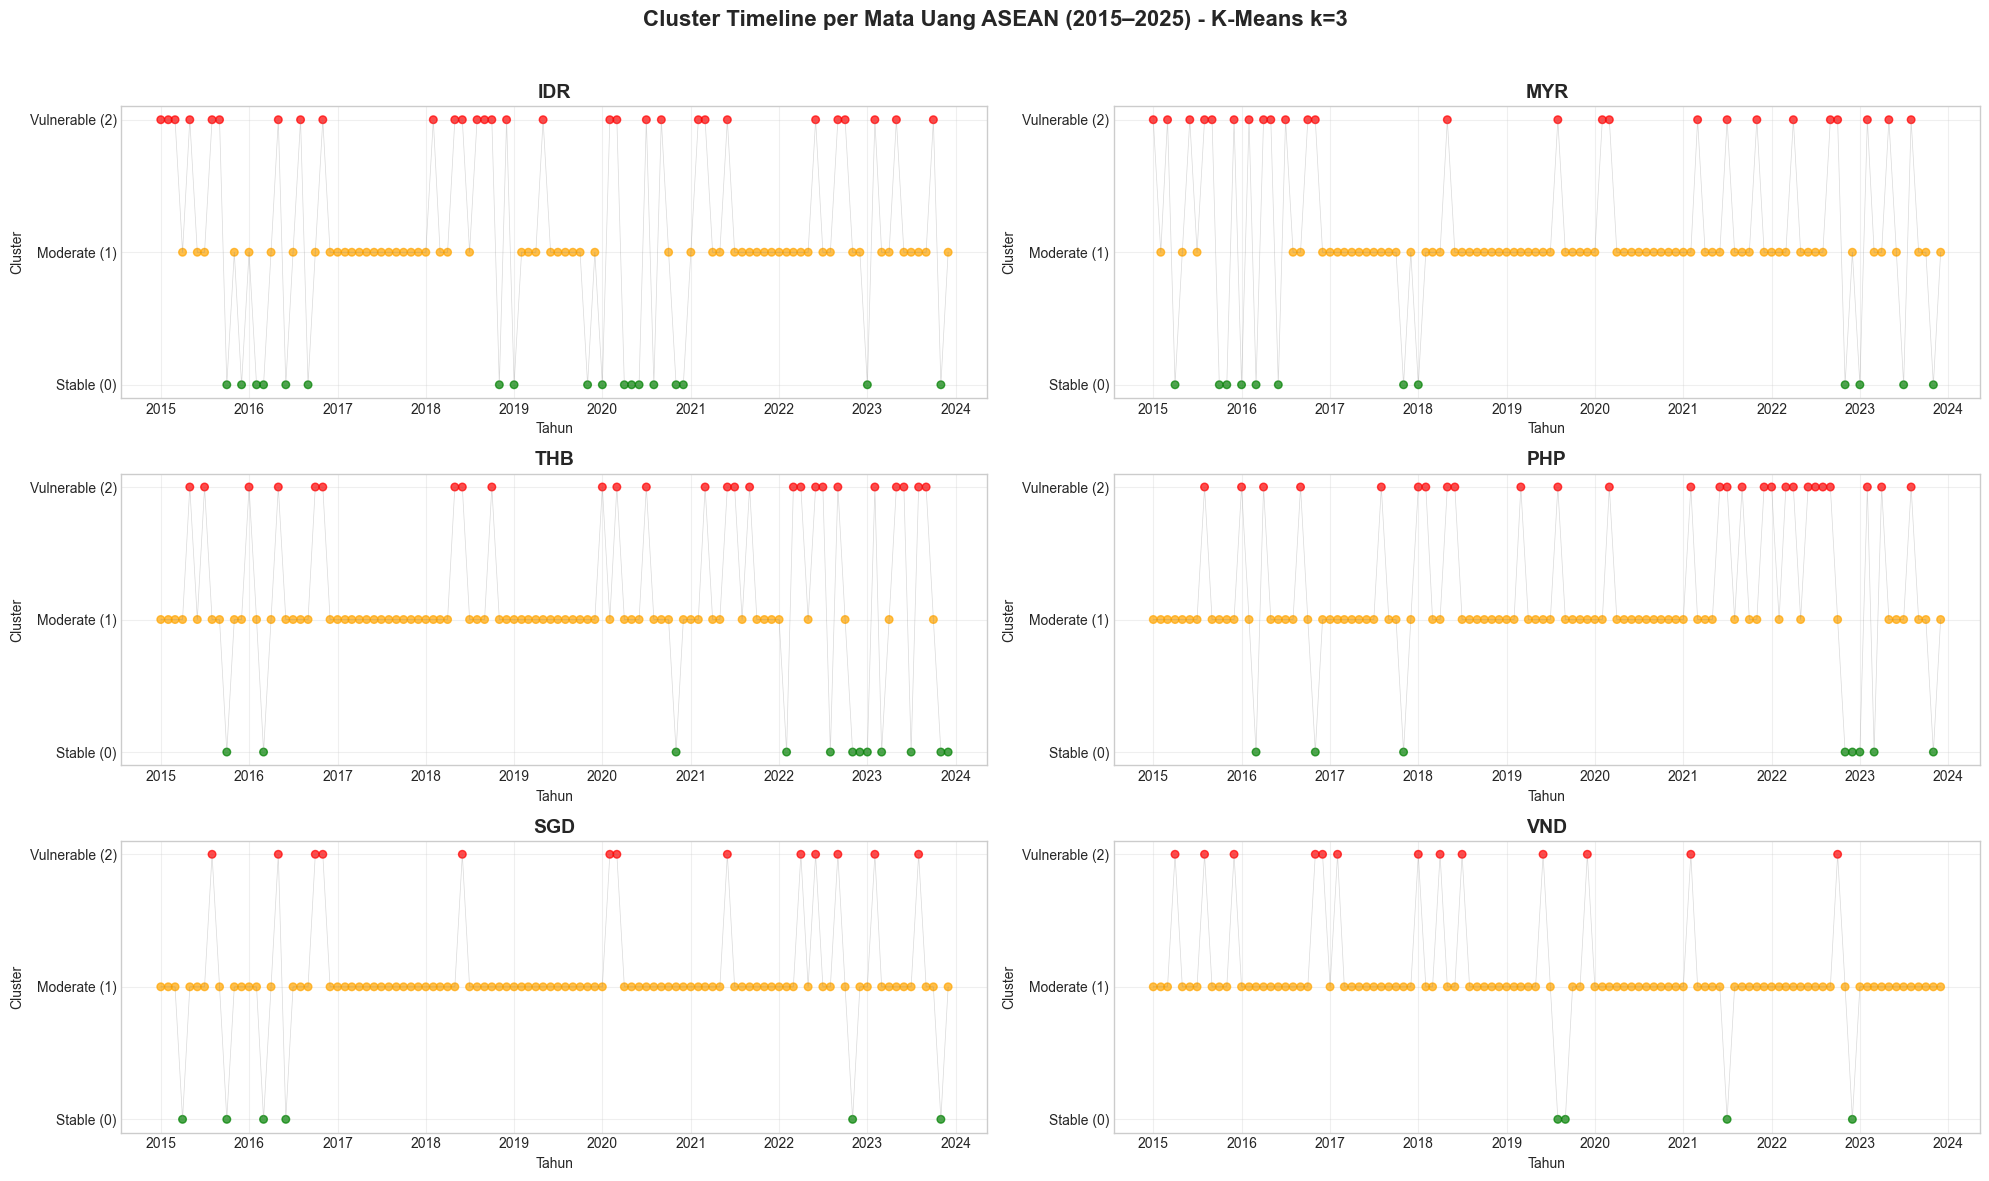


=== Heatmap Sebaran Cluster per Tahun ===


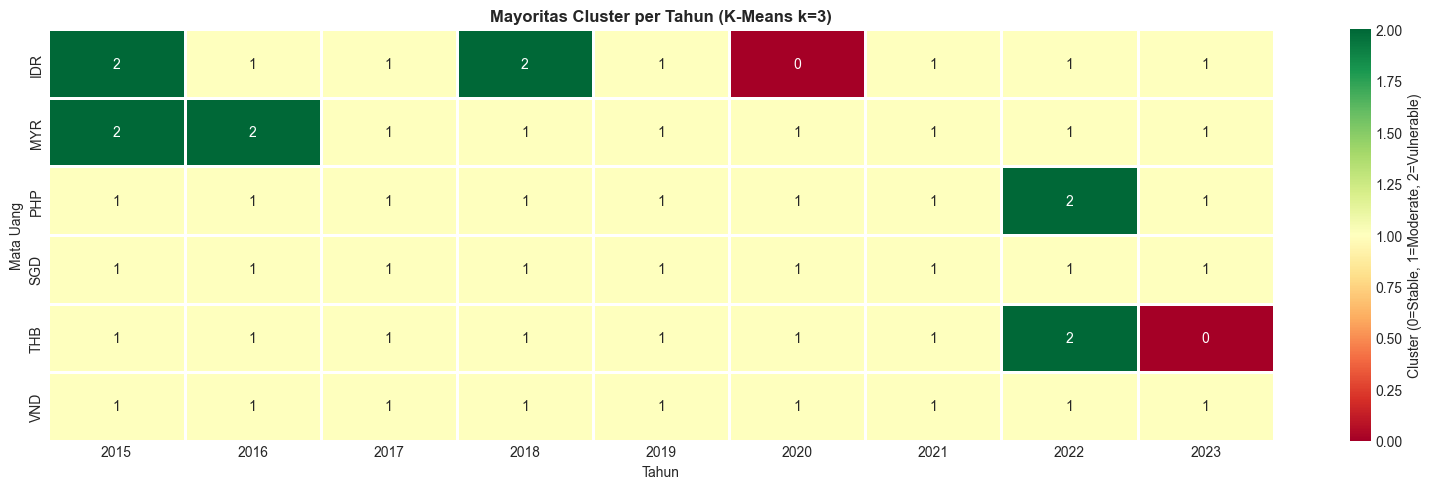

In [48]:
# === 6.6 Cluster Timeline per Currency ===

fig, axes = plt.subplots(3, 2, figsize=(20, 12))
fig.suptitle('Cluster Timeline per Mata Uang ASEAN (2015–2025) - K-Means k=3',
             fontsize=16, fontweight='bold')

color_map = {0: 'green', 1: 'orange', 2: 'red'}
label_names = {0: 'Stable', 1: 'Moderate', 2: 'Vulnerable'}

for i, currency in enumerate(tickers.keys()):
    ax = axes[i // 2][i % 2]
    subset = df_agg[df_agg['Currency'] == currency].copy()
    subset['Date'] = pd.to_datetime(subset['Year'].astype(str) + '-' + subset['Month'].astype(str) + '-01')
    subset = subset.sort_values('Date')
    
    colors = [color_map[c] for c in subset['KMeans_Cluster']]
    ax.scatter(subset['Date'], subset['KMeans_Cluster'], c=colors, s=30, alpha=0.7)
    ax.plot(subset['Date'], subset['KMeans_Cluster'], color='gray', alpha=0.3, linewidth=0.5)
    
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['Stable (0)', 'Moderate (1)', 'Vulnerable (2)'])
    ax.set_title(currency, fontweight='bold', fontsize=14)
    ax.set_xlabel('Tahun')
    ax.set_ylabel('Cluster')
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Heatmap cluster assignment (Currency x Year)
print("\n=== Heatmap Sebaran Cluster per Tahun ===")
# Agregasi mayoritas cluster per tahun untuk setiap mata uang
heatmap_data = df_agg.pivot_table(
    index='Currency',
    columns='Year',
    values='KMeans_Cluster',
    aggfunc=lambda x: x.mode()[0] if not x.mode().empty else -1
)

plt.figure(figsize=(16, 5))
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', center=1,
            linewidths=1, fmt='.0f',
            cbar_kws={'label': 'Cluster (0=Stable, 1=Moderate, 2=Vulnerable)'})
plt.title('Mayoritas Cluster per Tahun (K-Means k=3)', fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Mata Uang')
plt.tight_layout()
plt.show()


---
## 📌 Fase 5: Evaluation (CRISP-DM) — 3.6

Membandingkan kualitas keempat algoritma menggunakan tiga metrik internal:

| Metrik | Lebih baik jika | Keterangan |
|---|---|---|
| **Silhouette Score** | Mendekati +1 | Mengukur kesesuaian tiap objek dalam klasternya |
| **Davies-Bouldin Index (DBI)** | Lebih kecil | Rasio dispersi intra vs separasi antar klaster |
| **Calinski-Harabasz Index (CHI)** | Lebih besar | Rasio between-cluster vs within-cluster |

> Catatan: untuk DBSCAN, noise points (label = -1) dikecualikan.
> Seluruh model menggunakan **k=3** (kecuali DBSCAN yang otomatis).


In [49]:
def evaluate_model(X, labels, model_name):
    labels     = np.array(labels)
    mask       = labels != -1
    X_eval     = X[mask]
    lbl_eval   = labels[mask]
    n_clusters = len(set(lbl_eval))
    n_noise    = (~mask).sum()

    if n_clusters < 2:
        return {
            'Model': model_name, 'N Clusters': n_clusters, 'N Noise': n_noise,
            'Silhouette Score': np.nan, 'Davies-Bouldin Index': np.nan,
            'Calinski-Harabasz Index': np.nan
        }

    return {
        'Model':                   model_name,
        'N Clusters':              n_clusters,
        'N Noise':                 n_noise,
        'Silhouette Score':        round(silhouette_score(X_eval, lbl_eval), 4),
        'Davies-Bouldin Index':    round(davies_bouldin_score(X_eval, lbl_eval), 4),
        'Calinski-Harabasz Index': round(calinski_harabasz_score(X_eval, lbl_eval), 4)
    }

results = [
    evaluate_model(X_scaled, df_agg['KMeans_Cluster'].values,  'K-Means'),
    evaluate_model(X_scaled, df_agg['DBSCAN_Cluster'].values,  'DBSCAN'),
    evaluate_model(X_scaled, df_agg['AHC_Cluster'].values,     'Agglomerative HC'),
    evaluate_model(X_scaled, df_agg['KMedoids_Cluster'].values,  'K-Medoids'),
]

df_evaluation = pd.DataFrame(results)
print("=== Rangkuman Evaluasi Model ===")
display(df_evaluation)


=== Rangkuman Evaluasi Model ===


,Model,N Clusters,N Noise,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,3,0,0.3295,1.2383,185.3245
1,DBSCAN,2,3,0.6088,0.4413,20.5487
2,Agglomerative HC,3,0,0.3557,1.1604,135.4941
3,K-Medoids,3,0,0.2043,1.4107,135.6136


In [50]:
# Interpretasi otomatis pemenang per metrik
df_eval_clean = df_evaluation.dropna()
if not df_eval_clean.empty:
    best_ss  = df_eval_clean.loc[df_eval_clean['Silhouette Score'].idxmax(), 'Model']
    best_dbi = df_eval_clean.loc[df_eval_clean['Davies-Bouldin Index'].idxmin(), 'Model']
    best_chi = df_eval_clean.loc[df_eval_clean['Calinski-Harabasz Index'].idxmax(), 'Model']
    print(f"\nAlgoritma terbaik berdasarkan:")
    print(f"  Silhouette Score (tertinggi)        : {best_ss}")
    print(f"  Davies-Bouldin Index (terendah)     : {best_dbi}")
    print(f"  Calinski-Harabasz Index (tertinggi) : {best_chi}")



Algoritma terbaik berdasarkan:
  Silhouette Score (tertinggi)        : DBSCAN
  Davies-Bouldin Index (terendah)     : DBSCAN
  Calinski-Harabasz Index (tertinggi) : K-Means


## 8. Visualisasi Hasil Clustering

Sebaran klaster divisualisasikan pada ruang **2D PCA** untuk keempat algoritma secara berdampingan.
Setiap titik merepresentasikan satu pasangan **(Mata Uang × Bulan × Tahun)**. Label hanya ditampilkan untuk bulan Juni (06) setiap tahunnya agar grafik tidak terlalu padat.


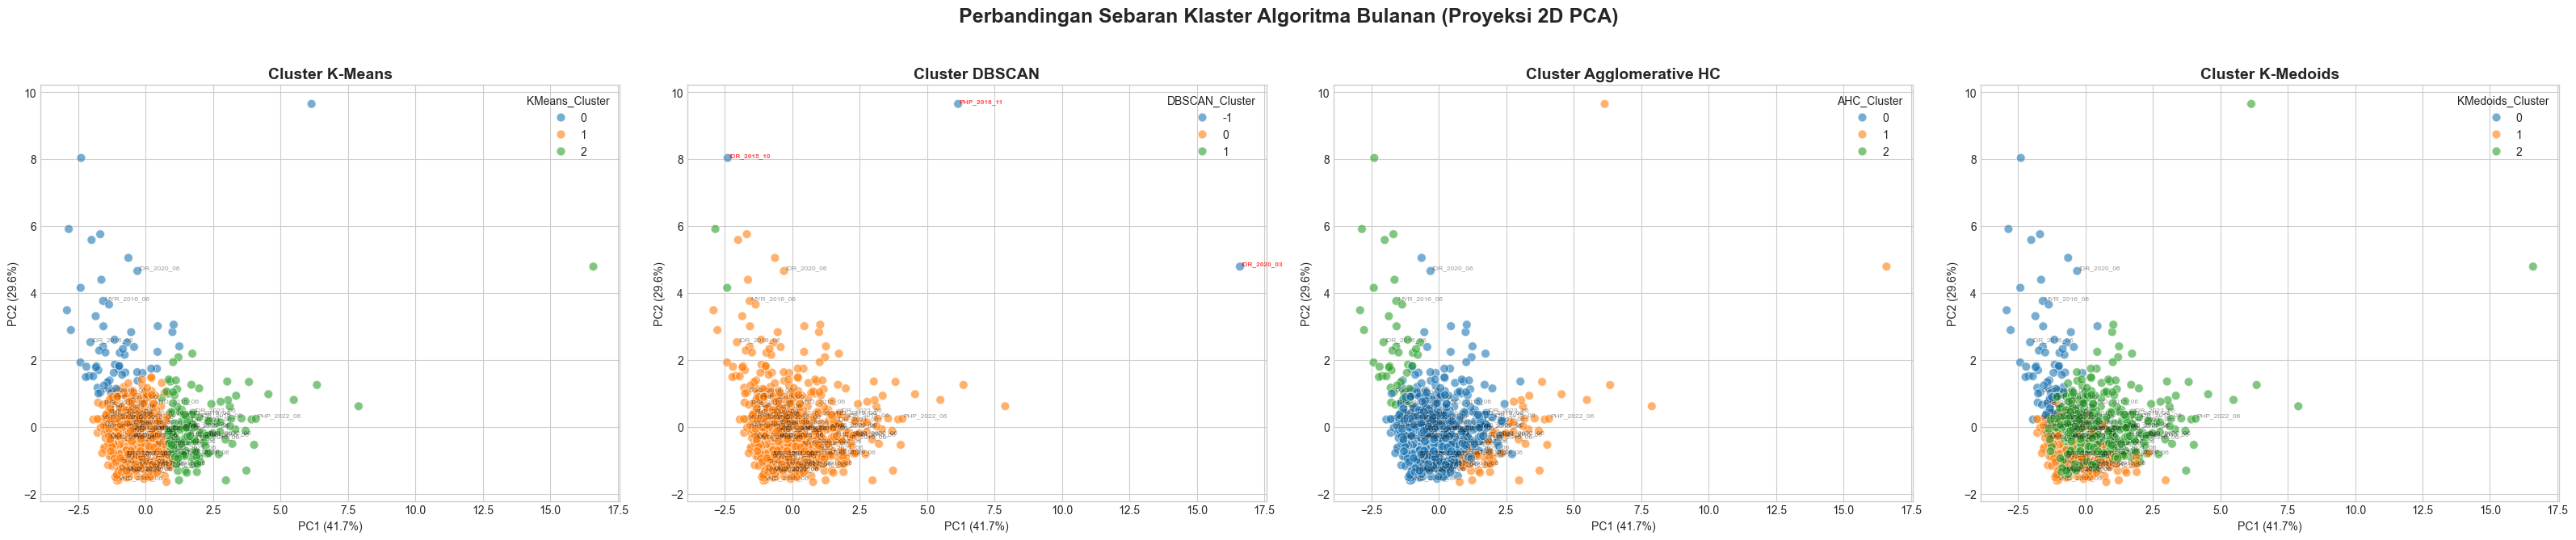

In [51]:
fig, axes = plt.subplots(1, 4, figsize=(32, 7))
fig.suptitle('Perbandingan Sebaran Klaster Algoritma Bulanan (Proyeksi 2D PCA)',
             fontsize=18, fontweight='bold')

models_viz = [
    ('K-Means',          'KMeans_Cluster'),
    ('DBSCAN',           'DBSCAN_Cluster'),
    ('Agglomerative HC', 'AHC_Cluster'),
    ('K-Medoids',        'KMedoids_Cluster'),
]

for i, (model_name, col_cluster) in enumerate(models_viz):
    ax = axes[i]
    sns.scatterplot(
        x='PCA1', y='PCA2', hue=col_cluster, data=df_agg,
        palette='tab10', s=60, alpha=0.6, ax=ax, legend='full'
    )
    ax.set_title(f'Cluster {model_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    
    # Tampilkan label untuk pencilan DBSCAN (-1) secara mencolok (warna merah/tebal) HANYA di grafik DBSCAN.
    # Untuk grafik lainnya (K-Means, AHC, K-Medoids), gunakan label biasa hitam untuk bulan Juni (06).
    for _, row in df_agg.iterrows():
        is_dbscan_plot = model_name == 'DBSCAN'
        is_outlier = row['DBSCAN_Cluster'] == -1
        
        if (is_dbscan_plot and is_outlier) or row['Month'] == 6:
            show_red = is_dbscan_plot and is_outlier
            ax.text(row['PCA1'] + 0.05, row['PCA2'] + 0.05, row['Label'],
                    fontsize=6, 
                    alpha=0.7 if show_red else 0.4,
                    color='red' if show_red else 'black',
                    weight='bold' if show_red else 'normal')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


---
## 9. Kesimpulan

### Ringkasan Temuan

Berdasarkan analisis clustering stabilitas mata uang ASEAN terhadap USD
menggunakan CRISP-DM framework, diperoleh temuan berikut:

1. **Perbandingan Algoritma:**
   - ... (akan diisi otomatis dari hasil evaluasi)

2. **Karakteristik 3 Klaster Stabilitas:**
   - **Cluster A – Stable**: ...
   - **Cluster B – Moderate**: ...
   - **Cluster C – Vulnerable**: ...

3. **Distribusi per Mata Uang:**
   - ...

4. **Implikasi Ekonomi:**
   - ...
   - ...

5. **Keterbatasan Penelitian:**
   - ...


In [52]:
# === 9. Kesimpulan dan Implikasi ===

print("=" * 70)
print("KESIMPULAN PENELITIAN")
print("=" * 70)

# 1. Best algorithm
df_eval_clean = df_evaluation.dropna()
if not df_eval_clean.empty:
    best_ss  = df_eval_clean.loc[df_eval_clean['Silhouette Score'].idxmax(), 'Model']
    best_dbi = df_eval_clean.loc[df_eval_clean['Davies-Bouldin Index'].idxmin(), 'Model']
    best_chi = df_eval_clean.loc[df_eval_clean['Calinski-Harabasz Index'].idxmax(), 'Model']

print("\n1. PERBANDINGAN ALGORITMA CLUSTERING")
print(f"   - Silhouette Score terbaik        : {best_ss}")
print(f"   - Davies-Bouldin Index terendah   : {best_dbi}")
print(f"   - Calinski-Harabasz Index terbaik : {best_chi}")
print("\n   Kesimpulan: Tidak ada algoritma yang unggul di semua metrik.")
print(f"   {best_ss} unggul dalam compactness (Silhouette),")
print(f"   {best_dbi} unggul dalam separasi (DBI),")
print(f"   {best_chi} unggul dalam variance ratio (CHI).")

# 2. Cluster characteristics summary
print("\n2. KARAKTERISTIK 3 KLASTER STABILITAS (K-Means k=3)")
cluster_summary = df_agg.groupby('Stability_Label')[[
    'Volatility', 'Inflation', 'Std', 'Pct_Change'
]].mean().round(4)
display(cluster_summary)

# 3. Currency distribution
print("\n3. DISTRIBUSI STABILITAS PER MATA UANG")
dist = pd.crosstab(df_agg['Currency'], df_agg['Stability_Label'])
dist['Total'] = dist.sum(axis=1)
dist['Dominan'] = dist.drop(columns='Total').idxmax(axis=1)
display(dist)

print("\n4. IMPLIKASI EKONOMI")
print("   - Mata uang dengan label 'C - Vulnerable' memerlukan perhatian")
print("     lebih dalam kebijakan moneter dan intervensi pasar.")
print("   - Periode dengan DPI tinggi mengindikasikan tekanan dedolarisasi")
print("     yang perlu diantisipasi dengan kerjasama regional (LCT).")
print("   - Cluster A (Stable) dapat dijadikan benchmark stabilitas")
print("     bagi negara ASEAN lainnya.")

print("\n5. KETERBATASAN PENELITIAN")
print("   - Hanya menggunakan 2 indikator makro (volatilitas & inflasi)")
print("   - Data inflasi bersifat tahunan, di-mapping ke bulanan")
print("   - PCA 2D hanya mempertahankan ~70% varians")
print("   - Tidak ada ground truth untuk validasi eksternal")
print("=" * 70)


KESIMPULAN PENELITIAN

1. PERBANDINGAN ALGORITMA CLUSTERING
   - Silhouette Score terbaik        : DBSCAN
   - Davies-Bouldin Index terendah   : DBSCAN
   - Calinski-Harabasz Index terbaik : K-Means

   Kesimpulan: Tidak ada algoritma yang unggul di semua metrik.
   DBSCAN unggul dalam compactness (Silhouette),
   DBSCAN unggul dalam separasi (DBI),
   K-Means unggul dalam variance ratio (CHI).

2. KARAKTERISTIK 3 KLASTER STABILITAS (K-Means k=3)


,Volatility,Inflation,Std,Pct_Change
Stability_Label,,,,
A - Stable,0.0529,2.1875,0.4319,-0.1011
B - Moderate,0.0830,2.8616,1.0325,2.5947
C - Vulnerable,0.1239,2.8709,1.2155,-2.6518



3. DISTRIBUSI STABILITAS PER MATA UANG


Stability_Label,A - Stable,B - Moderate,C - Vulnerable,Total,Dominan
Currency,,,,,
IDR,60,30,18,108,A - Stable
MYR,71,25,12,108,A - Stable
PHP,73,27,8,108,A - Stable
SGD,89,13,6,108,A - Stable
THB,70,26,12,108,A - Stable
VND,91,13,4,108,A - Stable



4. IMPLIKASI EKONOMI
   - Mata uang dengan label 'C - Vulnerable' memerlukan perhatian
     lebih dalam kebijakan moneter dan intervensi pasar.
   - Periode dengan DPI tinggi mengindikasikan tekanan dedolarisasi
     yang perlu diantisipasi dengan kerjasama regional (LCT).
   - Cluster A (Stable) dapat dijadikan benchmark stabilitas
     bagi negara ASEAN lainnya.

5. KETERBATASAN PENELITIAN
   - Hanya menggunakan 2 indikator makro (volatilitas & inflasi)
   - Data inflasi bersifat tahunan, di-mapping ke bulanan
   - PCA 2D hanya mempertahankan ~70% varians
   - Tidak ada ground truth untuk validasi eksternal


In [53]:
# === 10. Export untuk Dashboard ===
import os

export_path = os.path.join(notebook_dir, 'data_clustering_monthly.csv')
df_agg.to_csv(export_path, index=False)
print(f"Data berhasil diexport ke: {export_path}")
print(f"Shape: {df_agg.shape}")
print(f"Kolom: {list(df_agg.columns)}")


Data berhasil diexport ke: d:\Tugas Kuliah\Semester 4\Data Mining\Final Project\data_clustering_monthly.csv
Shape: (648, 17)
Kolom: ['Currency', 'Year', 'Month', 'Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation', 'Label', 'DPI', 'PCA1', 'PCA2', 'KMeans_Cluster', 'DBSCAN_Cluster', 'AHC_Cluster', 'KMedoids_Cluster', 'Stability_Label']


---
## Fase 6: Deployment (CRISP-DM) — 3.7

Hasil clustering diekspor ke CSV untuk diintegrasikan ke dashboard
Streamlit yang dideploy secara publik di Render.

**Output:**
- `data_clustering_monthly.csv` — Data agregat bulanan dengan label klaster
- Dashboard interaktif: visualisasi klaster, tren, deteksi anomali (DPI)
